In [18]:
# === Cell A0.1: Setup & Config ===
# Expected runtime: <5s
# Outputs: prints package versions and file paths

import pandas as pd
import numpy as np
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Paths to input files (adjust if needed)
CONFIG = {
    "paths": {
        "gene_table": "gene_expr_CeNGEN_base_mapped.csv",   # neuron × gene
        "motif_table": "motif_participation_profiles.csv",  # neuron × motifs
        "lineage_table": "lineage_function_map.tsv",        # neuron × lineage
        "confounds_table": "neuron_master.csv"              # neuron metadata
    }
}

print("PhaseA Config Paths:")
for k,v in CONFIG["paths"].items():
    print(f" - {k}: {v}")


PhaseA Config Paths:
 - gene_table: gene_expr_CeNGEN_base_mapped.csv
 - motif_table: motif_participation_profiles.csv
 - lineage_table: lineage_function_map.tsv
 - confounds_table: neuron_master.csv


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [19]:
# === Cell A1.1: Load Data ===
# Expected runtime: <10s
# Outputs: shapes + first few rows of each table

# Load gene expression (neuron × gene)
G_raw = pd.read_csv(CONFIG["paths"]["gene_table"], index_col=0)

# Load motif participation (neuron × motif features)
M_raw = pd.read_csv(CONFIG["paths"]["motif_table"])
motif_id_col = "Neuron" if "Neuron" in M_raw.columns else M_raw.columns[0]
M_raw = M_raw.set_index(motif_id_col)

# Load lineage features
L_raw = pd.read_csv(CONFIG["paths"]["lineage_table"], sep="\t")
lineage_id_col = "Neuron" if "Neuron" in L_raw.columns else L_raw.columns[0]
L_raw = L_raw.set_index(lineage_id_col)

# Load confounds
C_raw = pd.read_csv(CONFIG["paths"]["confounds_table"])
confound_id_col = "Neuron" if "Neuron" in C_raw.columns else C_raw.columns[0]
C_raw = C_raw.set_index(confound_id_col)

print("Shapes:")
print(" G_raw (gene expr):", G_raw.shape)
print(" M_raw (motifs):", M_raw.shape)
print(" L_raw (lineage):", L_raw.shape)
print(" C_raw (confounds):", C_raw.shape)

print("\nPreview G_raw:")
print(G_raw.iloc[:3, :5])


Shapes:
 G_raw (gene expr): (838, 22469)
 M_raw (motifs): (1533, 418)
 L_raw (lineage): (1533, 10)
 C_raw (confounds): (1533, 78)

Preview G_raw:
      WBGene00010957  WBGene00010958  WBGene00014454  WBGene00010959  \
AINL      232.125000       26.125000       18.125000       18.375000   
AINR      232.125000       26.125000       18.125000       18.375000   
ASIR      215.166667       21.333333       17.833333        7.833333   

      WBGene00010960  
AINL           77.75  
AINR           77.75  
ASIR           53.00  


In [20]:
# === Cell A1.2: Normalize IDs & Align ===
# Expected runtime: <5s
# Outputs: intersection counts + aligned shapes

# Helper: strip whitespace & unify neuron IDs
def clean_index(df):
    df.index = df.index.astype(str).str.strip()
    return df

G_raw = clean_index(G_raw)
M_raw = clean_index(M_raw)
L_raw = clean_index(L_raw)
C_raw = clean_index(C_raw)

# Intersect neurons across all four sources
common_neurons = (
    set(G_raw.index) &
    set(M_raw.index) &
    set(L_raw.index) &
    set(C_raw.index)
)
common_neurons = sorted(common_neurons)

print("Neuron coverage across datasets:")
print(" G_raw:", len(G_raw.index))
print(" M_raw:", len(M_raw.index))
print(" L_raw:", len(L_raw.index))
print(" C_raw:", len(C_raw.index))
print("\n Common intersection:", len(common_neurons))

# Subset all to common set
G = G_raw.loc[common_neurons]
M = M_raw.loc[common_neurons]
L = L_raw.loc[common_neurons]
C = C_raw.loc[common_neurons]

print("\nAligned shapes:")
print(" G (expr):", G.shape)
print(" M (motifs):", M.shape)
print(" L (lineage):", L.shape)
print(" C (confounds):", C.shape)


Neuron coverage across datasets:
 G_raw: 838
 M_raw: 1533
 L_raw: 1533
 C_raw: 1533

 Common intersection: 222

Aligned shapes:
 G (expr): (838, 22469)
 M (motifs): (838, 418)
 L (lineage): (838, 10)
 C (confounds): (838, 78)


In [21]:
# === Cell A2.1: Preprocess Gene Expression ===
# Expected runtime: 1–2 min (PCA on ~22k genes)
# Outputs: reduced PCA matrix (neurons × 200 PCs)

# Winsorize (cap extreme values)
G_winsor = G.clip(lower=G.quantile(0.01, axis=0), upper=G.quantile(0.99, axis=0), axis=1)

# Z-score standardization
scaler = StandardScaler(with_mean=True, with_std=True)
G_scaled = scaler.fit_transform(G_winsor)

# PCA reduction to 200 latent gene programs
pca = PCA(n_components=200, random_state=0)
G_pca = pca.fit_transform(G_scaled)
G_pca = pd.DataFrame(G_pca, index=G.index, columns=[f"PC{i+1}" for i in range(200)])

print("G_pca shape:", G_pca.shape)
print("Explained variance (first 10 PCs):", pca.explained_variance_ratio_[:10].round(4))


G_pca shape: (838, 200)
Explained variance (first 10 PCs): [0.2184 0.0636 0.0405 0.0338 0.0318 0.0297 0.0273 0.0248 0.0233 0.0219]


In [22]:
# === Cell A2.2: Prepare Lineage & Confounds ===
# Expected runtime: <5s
# Outputs: numeric lineage embeddings + cleaned confounds

# Lineage: keep numeric columns only
L_num = L.select_dtypes(include=[np.number]).copy()

# Confounds: select common metadata columns
# Example: degree, strength, class dummy-coded
C_num = C.select_dtypes(include=[np.number]).copy()

# Optional: one-hot encode class/type if available
if "Type" in C.columns:
    C_dummies = pd.get_dummies(C["Type"].astype(str), prefix="Type")
    C_num = pd.concat([C_num, C_dummies], axis=1)

print("L_num shape:", L_num.shape)
print("C_num shape:", C_num.shape)


L_num shape: (838, 7)
C_num shape: (838, 78)


In [23]:
# === Cell A3.1: Assemble Design Matrix ===
# Expected runtime: <10s
# Outputs: shape of X (design matrix) and Y (motif outcomes)

# Concatenate gene programs (PCA), lineage features, and confounds
X = pd.concat([G_pca, L_num, C_num], axis=1)

# Response = motif participation matrix
Y = M.copy()

print("Design matrix X shape:", X.shape)
print("Response matrix Y shape:", Y.shape)

# Sanity check alignment
assert all(X.index == Y.index), "Index mismatch between X and Y!"
print("\n✅ X and Y are aligned on", len(X.index), "neurons")

print("\nPreview X (first 5 rows, first 10 features):")
print(X.iloc[:5, :10])

print("\nPreview Y (first 5 rows, first 10 motifs):")
print(Y.iloc[:5, :10])


Design matrix X shape: (838, 285)
Response matrix Y shape: (838, 418)

✅ X and Y are aligned on 838 neurons

Preview X (first 5 rows, first 10 features):
            PC1       PC2       PC3       PC4      PC5       PC6       PC7  \
ADAL -23.250361 -3.513443 -2.619019 -7.139507  3.47578 -9.443258 -0.930894   
ADAL -23.250361 -3.513443 -2.619019 -7.139507  3.47578 -9.443258 -0.930894   
ADAL -23.250361 -3.513443 -2.619019 -7.139507  3.47578 -9.443258 -0.930894   
ADAL -23.250361 -3.513443 -2.619019 -7.139507  3.47578 -9.443258 -0.930894   
ADAR -23.250361 -3.513443 -2.619019 -7.139507  3.47578 -9.443258 -0.930894   

           PC8      PC9      PC10  
ADAL -5.658289 -1.98882 -2.496273  
ADAL -5.658289 -1.98882 -2.496273  
ADAL -5.658289 -1.98882 -2.496273  
ADAL -5.658289 -1.98882 -2.496273  
ADAR -5.658289 -1.98882 -2.496273  

Preview Y (first 5 rows, first 10 motifs):
        (0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan  \
Neuron                                                 
ADAL 

In [24]:
# === Cell A3.2: Save Aligned Datasets ===
# Expected runtime: <5s
# Outputs: CSV files saved locally for reproducibility

X_out = "PhaseA_X_design.csv"
Y_out = "PhaseA_Y_motifs.csv"

X.to_csv(X_out)
Y.to_csv(Y_out)

print("Saved design matrix →", X_out, "shape:", X.shape)
print("Saved motif outcomes →", Y_out, "shape:", Y.shape)


Saved design matrix → PhaseA_X_design.csv shape: (838, 285)
Saved motif outcomes → PhaseA_Y_motifs.csv shape: (838, 418)


In [29]:
# === Cell A4.1: Safe + Fast Feature Pre-screening (Pearson + MI) ===
# Expected runtime: ~1–2 min
# Outputs: reduced design matrix X_screened

from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm

# Parameters
TOP_K_PER_MOTIF = 50
np.random.seed(0)

selected_features = set()

# Ensure all features are numeric floats
X_float = X.astype(float)
X_values = X_float.to_numpy(dtype=np.float64)
X_cols = X_float.columns
n_features = X_values.shape[1]

# Precompute means and stds for features
X_mean = X_values.mean(axis=0)
X_std = X_values.std(axis=0)

# Iterate motifs with progress bar
for motif in tqdm(Y.columns, desc="Pre-screening motifs"):
    y = Y[motif].values.astype(float)
    if np.std(y) < 1e-6:
        continue

    # Pearson correlation (vectorized, column-wise)
    y_mean = y.mean()
    y_std = y.std()
    if y_std < 1e-6:
        continue
    cov = ((X_values - X_mean) * (y - y_mean)[:, None]).mean(axis=0)
    corr = cov / (X_std * y_std)
    corr = np.nan_to_num(corr)

    pearson_top_idx = np.argsort(np.abs(corr))[-TOP_K_PER_MOTIF:]
    pearson_top = X_cols[pearson_top_idx]

    # Mutual Information
    try:
        mi = mutual_info_regression(X_float, y, random_state=0, n_neighbors=5)
        mi_top_idx = np.argsort(mi)[-TOP_K_PER_MOTIF:]
        mi_top = X_cols[mi_top_idx]
    except Exception as e:
        print(f"⚠️ MI failed for motif {motif}: {e}")
        mi_top = []

    selected_features.update(pearson_top)
    selected_features.update(mi_top)

# Build reduced design matrix
selected_features = list(selected_features)
X_screened = X_float[selected_features].copy()

print("Original X shape:", X.shape)
print("Screened X shape:", X_screened.shape)
print("Total selected features:", len(selected_features))
print("\nPreview X_screened (first 5 rows, first 10 features):")
print(X_screened.iloc[:5, :10])


Pre-screening motifs: 100%|██████████| 418/418 [05:36<00:00,  1.24it/s]

Original X shape: (838, 285)
Screened X shape: (838, 280)
Total selected features: 273

Preview X_screened (first 5 rows, first 10 features):
          PC23        25        39         PC159      PC47         PC115  \
ADAL  2.051372 -0.134084  0.327167  2.151458e-14  2.134489 -1.986726e-14   
ADAL  2.051372  0.109480 -0.007022 -1.211601e-14  2.134489 -8.917073e-15   
ADAL  2.051372  0.194692  0.153104  1.474884e-14  2.134489 -1.986930e-14   
ADAL  2.051372  0.681752  0.225551  2.513212e-14  2.134489  2.478732e-15   
ADAR  2.051372  0.075479  0.523783 -1.326536e-14  2.134489  4.767927e-14   

             PC200      PC36       PC6        31  
ADAL -5.376852e-15 -9.080919 -9.443258  0.265271  
ADAL -3.909870e-15 -9.080919 -9.443258 -0.316546  
ADAL -9.575348e-15 -9.080919 -9.443258 -0.469595  
ADAL -6.389869e-15 -9.080919 -9.443258 -0.542396  
ADAR -1.731708e-14 -9.080919 -9.443258  0.645861  


In [30]:
# === Cell A4.2: Save Screened Matrix & Features ===
# Expected runtime: <5s

X_screened_out = "PhaseA_X_screened.csv"
feat_list_out = "PhaseA_selected_features.txt"

X_screened.to_csv(X_screened_out)

with open(feat_list_out, "w") as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

print("✅ Saved screened design matrix:", X_screened_out, "shape:", X_screened.shape)
print("✅ Saved feature list:", feat_list_out, "count:", len(selected_features))


✅ Saved screened design matrix: PhaseA_X_screened.csv shape: (838, 280)
✅ Saved feature list: PhaseA_selected_features.txt count: 273


In [31]:
# === Cell A5.1: Settings & Helpers (Stability Selection) ===
# Expected runtime: <10s
# Outputs: none (sets config + helpers)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from tqdm import tqdm
import numpy as np
import pandas as pd

A5_CFG = {
    "bootstrap_B": 200,         # number of bootstrap resamples
    "stability_tau": 0.70,      # frequency threshold for consensus edges
    "alpha_cv_folds": 5,        # folds for LassoCV
    "alpha_grid_size": 50,      # number of alphas to search
    "random_state": 1337
}

rng = np.random.default_rng(A5_CFG["random_state"])

# Pre-standardize X_screened once (fit on full X; apply within each bootstrap)
Xscaler = StandardScaler(with_mean=True, with_std=True)
X_std = pd.DataFrame(
    Xscaler.fit_transform(X_screened.astype(float)),
    index=X_screened.index,
    columns=X_screened.columns
)

# We'll standardize y motif-wise as we go
def zscore_vec(v):
    v = np.asarray(v, dtype=float)
    mu, sd = v.mean(), v.std()
    if sd < 1e-8:
        return None  # constant target; skip
    return (v - mu) / sd


In [32]:
# === Cell A5.2: Alpha tuning per motif with LassoCV ===
# Expected runtime: ~2–5 min (418 motifs × CV on ~280 features)
# Outputs: dict of best alpha per motif

alphas = np.logspace(-3, 1, A5_CFG["alpha_grid_size"])
motif_to_alpha = {}

for motif in tqdm(Y.columns, desc="Alpha CV per motif"):
    y = zscore_vec(Y[motif].values)
    if y is None:
        motif_to_alpha[motif] = None  # constant; will be skipped
        continue
    # Fit LassoCV once on full (standardized) data
    lcv = LassoCV(alphas=alphas, cv=A5_CFG["alpha_cv_folds"], random_state=A5_CFG["random_state"], n_jobs=None)
    lcv.fit(X_std, y)
    motif_to_alpha[motif] = float(lcv.alpha_)

# Quick summary
valid = [m for m,a in motif_to_alpha.items() if a is not None]
print(f"Motifs with tuned alpha: {len(valid)} / {len(motif_to_alpha)}")
print("Example alphas:", {m: motif_to_alpha[m] for m in valid[:5]})


Alpha CV per motif:   1%|          | 3/418 [00:00<02:05,  3.31it/s]/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.07998483052864458, tolerance: 0.07402233712669305
  model = cd_fast.enet_coordinate_descent_gram(
Alpha CV per motif:   2%|▏         | 8/418 [00:02<02:06,  3.23it/s]/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.48735975136099796, tolerance: 0.07537307180282
  model = cd_fast.enet_coordinate_descent_gram(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.9427065607453642, tolerance: 0.075

Motifs with tuned alpha: 418 / 418
Example alphas: {'(0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan': 0.020235896477251564, '(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan': 0.029470517025518096, '(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan': 0.009540954763499945, '(0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan': 0.0517947467923121, '(0, 1)_(0, 2)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan': 0.0517947467923121}


In [33]:
# === Cell A5.3: Bootstrap Stability Selection ===
# Expected runtime: ~5–12 min (B=200; scales roughly linearly with B)
# Outputs: stability DataFrame (features × motifs) with selection frequencies

B = A5_CFG["bootstrap_B"]
features = X_std.columns
motifs = [m for m in Y.columns if motif_to_alpha.get(m) is not None]

# Initialize selection counts
select_counts = pd.DataFrame(0, index=features, columns=motifs, dtype=int)

N = X_std.shape[0]
idx_all = np.arange(N)

for b in tqdm(range(B), desc="Bootstrapping"):
    # Sample neurons with replacement
    boot_idx = rng.choice(idx_all, size=N, replace=True)
    Xb = X_std.iloc[boot_idx, :]
    
    for m in motifs:
        y = zscore_vec(Y[m].values[boot_idx])
        if y is None:
            continue
        alpha = motif_to_alpha[m]
        if alpha is None:
            continue
        # Fit Lasso with fixed alpha (from CV)
        model = Lasso(alpha=alpha, random_state=A5_CFG["random_state"], max_iter=5000)
        model.fit(Xb, y)
        # Record selected (non-zero) features
        nz = np.flatnonzero(model.coef_)
        if nz.size > 0:
            select_counts.loc[features[nz], m] += 1

# Convert counts → frequencies
stability = select_counts / B
print("Stability matrix shape:", stability.shape)
print("Sample stability column:")
print(stability.iloc[:10, :1])


Bootstrapping: 100%|██████████| 200/200 [05:22<00:00,  1.61s/it]

Stability matrix shape: (280, 418)
Sample stability column:
       (0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan
PC23                                          0.135
25                                            0.190
39                                            0.990
PC159                                         0.690
PC47                                          0.095
PC115                                         0.785
PC200                                         0.335
PC36                                          0.490
PC6                                           0.665
31                                            0.475


In [34]:
# === Cell A5.4: Consensus Edges & Saves ===
# Expected runtime: <10s
# Outputs: CSVs for stability and consensus edge list

tau = A5_CFG["stability_tau"]

# Melt stability to long-form edges
edges = (
    stability.stack()
    .reset_index()
    .rename(columns={"level_0": "feature", "level_1": "motif", 0: "freq"})
)

# Keep edges above threshold
consensus_edges = edges[edges["freq"] >= tau].sort_values("freq", ascending=False)

# Save artifacts
stability_out = "PhaseA_A5_stability.csv"
edges_out = "PhaseA_A5_consensus_edges_tau{:.2f}.csv".format(tau)

stability.to_csv(stability_out)
consensus_edges.to_csv(edges_out, index=False)

print("Saved stability matrix →", stability_out, stability.shape)
print("Saved consensus edges →", edges_out, consensus_edges.shape)

# Quick peek at top edges
print("\nTop consensus edges:")
print(consensus_edges.head(10))


Saved stability matrix → PhaseA_A5_stability.csv (280, 418)
Saved consensus edges → PhaseA_A5_consensus_edges_tau0.70.csv (3782, 3)

Top consensus edges:
                   feature                                              motif  \
102917      AvgRelatedness       (0, 1)_(1, 0)_(2, 1)_nan_nan_nan_nan_nan_nan   
70819            as_source  (0, 1)_(0, 2)_(1, 0)_(1, 2)_(2, 0)_(2, 1)_nan_...   
70849            as_source    (0, 0)_(0, 1)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan   
83305            as_target  (1, 0)_(1, 2)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...   
107947                   9       (1, 1)_(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan   
71157            as_source  (0, 2)_(1, 0)_(1, 2)_(2, 1)_(2, 2)_nan_nan_nan...   
116298     HDBSCAN_Cluster       (0, 1)_(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan   
58181   total_3node_motifs          (1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan_nan   
10480                    1       (0, 2)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan_nan   
13465                 PC10       (0,

In [36]:
# === Cell A6.1b: Hard Alignment Fix ===
# Expected runtime: <5s
# Outputs: prints final aligned sizes; sets Y_float aligned to X_std

def clean_index_inplace(df):
    df.index = df.index.astype(str).str.strip()
    return df

def dedupe_mean(df):
    if df.index.has_duplicates:
        df = df.groupby(level=0).mean()
    return df

# 1) Clean indices
X_std = clean_index_inplace(X_std)
Y_tmp = Y.astype(float).copy()
Y_tmp = clean_index_inplace(Y_tmp)

# 2) Collapse duplicates
X_std = dedupe_mean(X_std)
Y_tmp = dedupe_mean(Y_tmp)

# 3) Intersect and enforce the SAME order (use X_std as the anchor)
common = X_std.index.intersection(Y_tmp.index)
X_std = X_std.loc[common]
Y_float = Y_tmp.loc[common].reindex(X_std.index)

print("Aligned X_std:", X_std.shape)
print("Aligned Y_float:", Y_float.shape)
print("Same order?", (X_std.index.equals(Y_float.index)))


Aligned X_std: (222, 280)
Aligned Y_float: (222, 418)
Same order? True


In [38]:
# === Cell A6.2: DML Effect Estimation (cross-fitting) ===
# Expected runtime: ~10–20 min for ~3.8k edges (scales with edges and K)
# Outputs: effects DataFrame with effect, SE, t, p per edge

from numpy.linalg import lstsq

rng = np.random.default_rng(A6_CFG["random_state"])
N = X_std.shape[0]
idx_all = np.arange(N)

def zscore_vec(v):
    v = np.asarray(v, dtype=float)
    mu, sd = v.mean(), v.std()
    if sd < 1e-12:
        return None
    return (v - mu) / sd

def dml_effect(y, t, Z, k_folds=5, alpha=1.0):
    """
    Double Machine Learning (partialling-out) with cross-fitting.
    y: (N,) outcome
    t: (N,) treatment (parent feature)
    Z: (N, p) controls (exclude t)
    Returns: beta_hat, se, n_eff
    """
    N = len(y)
    folds = np.array_split(rng.permutation(N), k_folds)

    y_tilde_list, t_tilde_list = [], []
    for k in range(k_folds):
        test_idx = folds[k]
        train_idx = np.concatenate([folds[i] for i in range(k_folds) if i != k])

        Z_tr, Z_te = Z[train_idx], Z[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        t_tr, t_te = t[train_idx], t[test_idx]

        # Ridge nuisances
        ry = Ridge(alpha=alpha, fit_intercept=True)
        rt = Ridge(alpha=alpha, fit_intercept=True)

        ry.fit(Z_tr, y_tr)
        rt.fit(Z_tr, t_tr)

        y_hat = ry.predict(Z_te)
        t_hat = rt.predict(Z_te)

        y_tilde_list.append(y_te - y_hat)
        t_tilde_list.append(t_te - t_hat)

    y_tilde = np.concatenate(y_tilde_list)
    t_tilde = np.concatenate(t_tilde_list)

    # If no variance in residualized treatment
    if t_tilde.std() < 1e-10:
        return np.nan, np.nan, len(y_tilde)

    # OLS slope-only regression: beta = (t' y) / (t' t)
    beta_hat = float(np.dot(t_tilde, y_tilde) / np.dot(t_tilde, t_tilde))

    # Residuals
    resid = y_tilde - beta_hat * t_tilde
    dof = max(1, len(y_tilde) - 1)
    sigma2 = np.dot(resid, resid) / dof
    se = float(np.sqrt(sigma2 / np.dot(t_tilde, t_tilde)))

    return beta_hat, se, len(y_tilde)


# Pre-build arrays once
X_cols = X_std.columns.to_list()
X_mat = X_std.values  # (N, p)

effects = []  # rows: dict(feature, motif, beta, se, t, p, n)

# Outer loop over motifs (to get y once), inner loop over parents
for motif, parents in tqdm(motif_to_parents.items(), desc="A6 DML: motifs"):
    y_raw = Y_float[motif].values
    y = zscore_vec(y_raw)
    if y is None:
        continue

    for feat in parents:
        # Index of treatment feature
        try:
            j = X_cols.index(feat)
        except ValueError:
            # Feature not in X (shouldn't happen)
            continue

        t = X_mat[:, j]
        # Controls exclude the treatment column
        ctrl_mask = np.ones(len(X_cols), dtype=bool)
        ctrl_mask[j] = False
        Z = X_mat[:, ctrl_mask]

        # Run DML
        beta, se, n_eff = dml_effect(y, t, Z,
                                     k_folds=A6_CFG["K_folds"],
                                     alpha=A6_CFG["ridge_alpha"])

        # t-stat and two-sided p-value
        if np.isfinite(beta) and np.isfinite(se) and se > 0:
            t_val = beta / se
            p_val = 2 * (1 - t_dist.cdf(abs(t_val), df=max(1, n_eff - 2)))
        else:
            t_val, p_val = np.nan, np.nan

        effects.append({
            "feature": feat,
            "motif": motif,
            "beta": beta,
            "se": se,
            "t": t_val,
            "p": p_val,
            "n": n_eff
        })

effects_df = pd.DataFrame(effects)
print("A6 effects shape:", effects_df.shape)
print(effects_df.head())


A6 DML: motifs: 100%|██████████| 380/380 [01:15<00:00,  5.01it/s]

A6 effects shape: (3782, 7)
     feature                                              motif      beta  \
0  as_source  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  1.342652   
1  as_source  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  1.636327   
2  as_source  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  1.357029   
3  as_source  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  1.088780   
4          1  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ... -0.406836   

         se         t         p    n  
0  0.634023  2.117673  0.035325  222  
1  0.684517  2.390483  0.017669  222  
2  0.394440  3.440397  0.000695  222  
3  0.346225  3.144722  0.001892  222  
4  0.156335 -2.602341  0.009888  222  


In [39]:
# === Cell A6.3: Save Effects & Quick Summary ===
# Expected runtime: <10s
# Outputs: CSV of per-edge effects; top hits preview

A6_out = "PhaseA_A6_effects_DML.csv"
effects_df.to_csv(A6_out, index=False)

print("Saved DML effects →", A6_out, "rows:", effects_df.shape[0])

# Quick top hits by |t|
top_hits = effects_df.dropna(subset=["t"]).copy()
top_hits["abs_t"] = top_hits["t"].abs()
print("\nTop edges by |t|:")
print(top_hits.sort_values("abs_t", ascending=False).head(10)[
    ["feature", "motif", "beta", "se", "t", "p"]
])


Saved DML effects → PhaseA_A6_effects_DML.csv rows: 3782

Top edges by |t|:
     feature                                              motif      beta  \
2069    PC87  (0, 1)_(1, 0)_(1, 2)_(2, 0)_(2, 1)_(2, 2)_nan_...  0.405572   
3111    PC33    (0, 2)_(1, 1)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan  0.245732   
885     PC78  (0, 0)_(0, 2)_(1, 2)_(2, 1)_(2, 2)_nan_nan_nan...  0.279072   
3767    PC88          (2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan  0.297635   
2165    PC32  (0, 1)_(1, 0)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...  0.362465   
216     PC69  (0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 1)_nan_nan_nan... -0.273994   
3518    PC89       (1, 0)_(1, 2)_(2, 2)_nan_nan_nan_nan_nan_nan  0.341212   
457     PC82  (0, 0)_(0, 1)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan_...  0.305354   
3519    PC93       (1, 0)_(1, 2)_(2, 2)_nan_nan_nan_nan_nan_nan  0.428354   
1977     PC4  (0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 2)_nan_... -0.473077   

            se          t    p  
2069  0.012842  31.580904  0.0  
3111  0.00

In [40]:
# === Cell A7.1: Effect Size Matrix ===
# Expected runtime: <10s
# Outputs: effect_matrix (features × motifs)

# Use effects_df from A6 (feature, motif, beta)
effect_matrix = effects_df.pivot_table(index="feature",
                                       columns="motif",
                                       values="beta")

print("Effect matrix shape:", effect_matrix.shape)
print("Preview (first 5 features, first 5 motifs):")
print(effect_matrix.iloc[:5, :5])

# Save for reproducibility
A7_mat_out = "PhaseA_A7_effect_matrix.csv"
effect_matrix.to_csv(A7_mat_out)
print("✅ Saved effect matrix →", A7_mat_out)


Effect matrix shape: (259, 380)
Preview (first 5 features, first 5 motifs):
motif    (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_(2, 2)  \
feature                                                                   
0                                                      NaN                
1                                                      NaN                
10                                                     NaN                
12                                                     NaN                
13                                                     NaN                

motif    (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan  \
feature                                                                
0                                                      NaN             
1                                                -0.406836             
10                                                     NaN             
12                                    

In [41]:
# === Cell A7.2: PCA Embedding ===
# Expected runtime: <5s
# Outputs: PCA embeddings + variance explained

from sklearn.decomposition import PCA

# Fill NaNs with 0 (no effect)
X_eff = effect_matrix.fillna(0).T  # motifs × features

pca = PCA(n_components=10, random_state=1337)
motif_pca = pca.fit_transform(X_eff)

print("Explained variance (first 5 PCs):", pca.explained_variance_ratio_[:5])

# Save embeddings
motif_pca_df = pd.DataFrame(motif_pca, index=effect_matrix.columns,
                            columns=[f"PC{i+1}" for i in range(motif_pca.shape[1])])
motif_pca_df.to_csv("PhaseA_A7_motif_pca.csv")

print("✅ Saved motif PCA embedding → PhaseA_A7_motif_pca.csv shape:", motif_pca_df.shape)


Explained variance (first 5 PCs): [0.28165611 0.17339279 0.09359152 0.07762831 0.04009788]
✅ Saved motif PCA embedding → PhaseA_A7_motif_pca.csv shape: (380, 10)


In [42]:
# === Cell A7.3: t-SNE Embedding ===
# Expected runtime: ~1–3 min (depends on features)
# Outputs: 2D t-SNE embedding of motifs

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=1337, n_iter=2000)
motif_tsne = tsne.fit_transform(X_eff)

motif_tsne_df = pd.DataFrame(motif_tsne, index=effect_matrix.columns,
                             columns=["TSNE1", "TSNE2"])
motif_tsne_df.to_csv("PhaseA_A7_motif_tsne.csv")

print("✅ Saved motif t-SNE embedding → PhaseA_A7_motif_tsne.csv shape:", motif_tsne_df.shape)


/home/rohit/.local/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✅ Saved motif t-SNE embedding → PhaseA_A7_motif_tsne.csv shape: (380, 2)


In [44]:
# === Cell A7.4: Similarity Matrices ===
# Expected runtime: ~30s
# Outputs: cosine & KL similarity matrices (motif × motif)

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Convert to numpy arrays
X_eff_arr = effect_matrix.fillna(0).T.values  # motifs × features

# Normalize rows
X_eff_norm = X_eff_arr / (np.linalg.norm(X_eff_arr, axis=1, keepdims=True) + 1e-12)

# Cosine similarity
cos_sim = cosine_similarity(X_eff_norm)
cos_sim_df = pd.DataFrame(cos_sim, index=effect_matrix.columns, columns=effect_matrix.columns)
cos_sim_df.to_csv("PhaseA_A7_cosine_similarity.csv")

# KL divergence (symmetrized)
P = np.clip(X_eff_norm, 1e-9, 1.0)
P = P / P.sum(axis=1, keepdims=True)   # now works (numpy array)

kl_div = np.zeros((P.shape[0], P.shape[0]))
for i in range(P.shape[0]):
    for j in range(P.shape[0]):
        if i == j:
            continue
        kl_div[i, j] = 0.5 * (np.sum(P[i] * np.log(P[i] / P[j])) +
                              np.sum(P[j] * np.log(P[j] / P[i])))

kl_df = pd.DataFrame(kl_div, index=effect_matrix.columns, columns=effect_matrix.columns)
kl_df.to_csv("PhaseA_A7_kl_divergence.csv")

print("✅ Saved cosine similarity & KL divergence matrices")
print("Shapes:", cos_sim_df.shape, kl_df.shape)


✅ Saved cosine similarity & KL divergence matrices
Shapes: (380, 380) (380, 380)


In [45]:
# === Cell A7.5: Causal Similarity Network ===
# Expected runtime: <10s
# Outputs: edge list of motif–motif similarities

sim_thresh = 0.7  # threshold for cosine similarity
edges = []
for i, m1 in enumerate(effect_matrix.columns):
    for j, m2 in enumerate(effect_matrix.columns):
        if j <= i:  # upper triangle only
            continue
        if cos_sim[i, j] >= sim_thresh:
            edges.append((m1, m2, cos_sim[i, j]))

edges_df = pd.DataFrame(edges, columns=["motif1", "motif2", "cosine"])
edges_df.to_csv("PhaseA_A7_similarity_network.csv", index=False)

print("✅ Saved causal similarity network edges → PhaseA_A7_similarity_network.csv")
print("Edges above threshold:", len(edges_df))
print(edges_df.head())


✅ Saved causal similarity network edges → PhaseA_A7_similarity_network.csv
Edges above threshold: 9905
                                              motif1  \
0  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...   
1  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...   
2  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...   
3  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...   
4  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...   

                                              motif2    cosine  
0  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  0.747060  
1  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  1.000000  
2  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  1.000000  
3  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  0.921124  
4  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(2, 0)_(2, ...  1.000000  


In [46]:
# === Cell A8.1: Build Hypergraph (feature → motif) ===
# Expected runtime: <10s
# Outputs: hypergraph as dict and edge list

import itertools
import networkx as nx

# Load consensus edges if not in memory
try:
    _ = consensus_edges
except NameError:
    consensus_edges = pd.read_csv("PhaseA_A5_consensus_edges_tau0.70.csv")

# Hypergraph representation: dict {feature: [motifs]}
hypergraph = (consensus_edges.groupby("feature")["motif"]
                             .apply(list)
                             .to_dict())

print("Total features (hyperedges):", len(hypergraph))
print("Example feature → motifs (first 3):")
for f, ms in list(hypergraph.items())[:3]:
    print(f, "→", ms[:5], "...")

# Also build bipartite graph representation (NetworkX)
B = nx.Graph()
for f, motifs in hypergraph.items():
    for m in motifs:
        B.add_edge(f, m)

print("Bipartite graph nodes:", B.number_of_nodes(), "edges:", B.number_of_edges())

# Save bipartite edge list
nx.write_edgelist(B, "PhaseA_A8_bipartite.edgelist")
print("✅ Saved bipartite graph edge list → PhaseA_A8_bipartite.edgelist")


Total features (hyperedges): 259
Example feature → motifs (first 3):
0 → ['(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan', '(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(1, 1)_(1, 2)_(2, 0)_nan_nan_nan_nan', '(1, 0)_(1, 1)_(2, 1)_nan_nan_nan_nan_nan_nan', '(0, 2)_(1, 0)_(1, 1)_nan_nan_nan_nan_nan_nan'] ...
1 → ['(0, 2)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(1, 1)_(2, 1)_nan_nan_nan_nan_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(2, 0)_(2, 1)_nan_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan', '(0, 1)_(0, 2)_(2, 1)_nan_nan_nan_nan_nan_nan'] ...
10 → ['(0, 1)_(0, 2)_(1, 2)_(2, 0)_nan_nan_nan_nan_nan', '(0, 1)_(1, 1)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan', '(0, 1)_(1, 1)_(1, 2)_(2, 2)_nan_nan_nan_nan_nan', '(0, 2)_(1, 1)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan', '(0, 1)_(1, 1)_(2, 1)_nan_nan_nan_nan_nan_nan'] ...
Bipartite graph nodes: 639 edges: 3161
✅ Saved bipartite graph edge list → PhaseA_A8_bipartite.edgelist


In [47]:
# === Cell A8.2: Build Simplicial Complex (motif co-parent groups) ===
# Expected runtime: <30s
# Outputs: simplices (motif sets) + stats

simplices = []

# For each feature (parent), motifs it connects form a simplex
for motifs in hypergraph.values():
    if len(motifs) >= 2:
        simplices.append(tuple(sorted(set(motifs))))

# Deduplicate
simplices = list(set(simplices))

print("Total simplices:", len(simplices))
print("Example simplices (first 3):", simplices[:3])

# Save simplices to file
simplices_out = "PhaseA_A8_simplices.txt"
with open(simplices_out, "w") as f:
    for s in simplices:
        f.write(",".join(s) + "\n")

print("✅ Saved simplicial complex →", simplices_out)


Total simplices: 245
Example simplices (first 3): [('(0, 0)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan_nan', '(0, 1)_(0, 2)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan_nan_nan'), ('(0, 0)_(0, 2)_(1, 1)_(1, 2)_(2, 1)_(2, 2)_nan_nan_nan', '(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_(2, 2)_nan', '(0, 1)_(0, 2)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan_nan_nan', '(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan', '(0, 2)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan', '(0, 2)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan_nan'), ('(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(2, 0)_(2, 1)_nan_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 1)_(2, 2)_nan_nan_nan_nan', '(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan', '(0, 0)_(0, 1)_(0, 2)_(2, 1)_(2, 2)_nan_nan_nan_nan', '(0, 0)_(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 1)_(2, 2)_nan_nan', '(0, 0)_(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 1)_nan_nan_nan', '(0, 0)_(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 2)_nan_

In [48]:
# === Cell A8.3: Persistent Homology / Betti Numbers ===
# Expected runtime: depends (a few sec to 1–2 min)
# Outputs: Betti numbers per dimension

try:
    import gudhi
    gudhi_ok = True
except ImportError:
    gudhi_ok = False
    print("⚠️ gudhi not installed, falling back to simple Betti computation")

if gudhi_ok:
    # Build a Gudhi SimplexTree
    st = gudhi.SimplexTree()
    for s in simplices:
        st.insert(s)

    # Compute persistence
    st.compute_persistence()
    betti = st.betti_numbers()

    print("Betti numbers:", betti)

    # Save persistence diagram
    diag = st.persistence()
    gudhi.write_persistence_diagram(diag, "PhaseA_A8_persistence.diagram")
    print("✅ Saved persistence diagram → PhaseA_A8_persistence.diagram")
else:
    # Fallback: count connected components, loops via networkx
    motif_graph = nx.Graph()
    for s in simplices:
        motif_graph.add_edges_from(itertools.combinations(s, 2))

    betti0 = nx.number_connected_components(motif_graph)
    betti1 = len(list(nx.cycle_basis(motif_graph)))

    betti = {0: betti0, 1: betti1}
    print("Fallback Betti numbers:", betti)

# Save Betti numbers
pd.Series(betti).to_csv("PhaseA_A8_betti_numbers.csv")
print("✅ Saved Betti numbers → PhaseA_A8_betti_numbers.csv")


⚠️ gudhi not installed, falling back to simple Betti computation
Fallback Betti numbers: {0: 1, 1: 47105}
✅ Saved Betti numbers → PhaseA_A8_betti_numbers.csv


In [49]:
# === Cell A8.4: Save Summaries ===
# Expected runtime: <5s
# Outputs: CSVs of stats

# Feature degrees (how many motifs per feature)
feat_deg = pd.Series({f: len(ms) for f, ms in hypergraph.items()})
feat_deg.to_csv("PhaseA_A8_feature_degrees.csv")

# Motif degrees (how many features per motif)
motif_deg = consensus_edges.groupby("motif")["feature"].nunique()
motif_deg.to_csv("PhaseA_A8_motif_degrees.csv")

print("✅ Saved feature/motif degree distributions")
print("Feature degree stats:", feat_deg.describe())
print("Motif degree stats:", motif_deg.describe())


✅ Saved feature/motif degree distributions
Feature degree stats: count    259.000000
mean      14.602317
std       38.511049
min        1.000000
25%        4.000000
50%        7.000000
75%       13.000000
max      412.000000
dtype: float64
Motif degree stats: count    380.000000
mean       8.318421
std       12.762750
min        1.000000
25%        1.000000
50%        4.000000
75%       10.000000
max      102.000000
Name: feature, dtype: float64


In [56]:
# === Cell A9.1: Initialize CA State ===
# Expected runtime: <5s
# Outputs: initial state vector (motifs)

rng = np.random.default_rng(1337)

motifs = effect_matrix.columns.tolist()
n_motifs = len(motifs)

# Initial state: binary random
init_state = rng.choice([0, 1], size=n_motifs, p=[0.9, 0.1])

print("Motifs:", n_motifs)
print("Initial state (first 20):", init_state[:20])


Motifs: 380
Initial state (first 20): [0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [57]:
# === Cell A9.2: Build Motif→Motif Matrix + Update Rules ===
# Expected runtime: ~20s
# Outputs: square W matrix (motif×motif), update functions

edges = pd.read_csv("PhaseA_A6_effects_DML.csv")
edges_sig = edges.query("p < 0.05")  # keep only significant edges

# Map motifs to indices
motifs = sorted(edges_sig["motif"].unique())
motif_to_idx = {m: i for i, m in enumerate(motifs)}
n_motifs = len(motifs)

# Build motif→motif influence matrix
W = np.zeros((n_motifs, n_motifs))

for f, group in edges_sig.groupby("feature"):
    linked = group["motif"].values
    betas = group["beta"].values
    idxs = [motif_to_idx[m] for m in linked]
    for i, bi in zip(idxs, betas):
        for j, bj in zip(idxs, betas):
            if i != j:
                W[i, j] += bi * bj

# Normalize rows
W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)

print("Motif→Motif matrix shape:", W.shape)

# --- Update rules ---
def update_binary(state, W, thresh=0.0):
    """Binary threshold update rule."""
    new_state = W @ state
    return (new_state > thresh).astype(int)

def update_continuous(state, W, beta=1.0):
    """Continuous sigmoid update rule."""
    new_state = W @ state
    return 1 / (1 + np.exp(-beta * new_state))


Motif→Motif matrix shape: (311, 311)


In [58]:
# === Cell A9.3: Run Simulations (binary + continuous) ===
# Expected runtime: ~30s for T=50, seeds=5
# Outputs: trajectories arrays

T = 50
n_seeds = 5

trajectories_binary = []
trajectories_cont = []

for seed in range(n_seeds):
    state_bin = rng.choice([0, 1], size=n_motifs, p=[0.9, 0.1])
    state_cont = state_bin.astype(float)

    traj_bin = [state_bin.copy()]
    traj_cont = [state_cont.copy()]

    for t in range(1, T):
        state_bin = update_binary(state_bin, W, thresh=0.1)
        state_cont = update_continuous(state_cont, W, beta=1.0)

        traj_bin.append(state_bin.copy())
        traj_cont.append(state_cont.copy())

    trajectories_binary.append(np.vstack(traj_bin))   # (T, n_motifs)
    trajectories_cont.append(np.vstack(traj_cont))

trajectories_binary = np.stack(trajectories_binary)   # (n_seeds, T, n_motifs)
trajectories_cont = np.stack(trajectories_cont)

print("Binary trajectories shape:", trajectories_binary.shape)
print("Continuous trajectories shape:", trajectories_cont.shape)


Binary trajectories shape: (5, 50, 311)
Continuous trajectories shape: (5, 50, 311)


In [60]:
# === Cell A9.4: Emergent Property Analysis (Binary + Continuous, Fixed) ===
# Expected runtime: ~30s
# Outputs: entropy curves, attractor checks

from scipy.stats import entropy

def trajectory_entropy(traj):
    """Shannon entropy per timestep (binary vs continuous states)."""
    entropies = []
    for state in traj:
        if np.issubdtype(state.dtype, np.integer):  # binary states
            probs = np.bincount(state.astype(int), minlength=2) / len(state)
        else:  # continuous states
            hist, _ = np.histogram(state, bins=20, range=(0,1), density=True)
            probs = hist / np.sum(hist)
        entropies.append(entropy(probs))
    return entropies

def check_fixed_point(traj, tol=1e-3):
    """Check if final state converged (binary exact, continuous tolerance)."""
    if np.issubdtype(traj.dtype, np.integer):
        return int(np.all(traj[-1] == traj[-2]))
    else:
        return int(np.allclose(traj[-1], traj[-2], atol=tol))

# Analyze both binary + continuous
for label, trajectories in [("Binary", trajectories_binary),
                            ("Continuous", trajectories_cont)]:
    print(f"\n=== {label} Dynamics ===")
    for seed, traj in enumerate(trajectories):
        ent = trajectory_entropy(traj)
        fixed = check_fixed_point(traj)
        print(f"Seed {seed}: final entropy={ent[-1]:.3f}, fixed_point={fixed}")



=== Binary Dynamics ===
Seed 0: final entropy=0.310, fixed_point=1
Seed 1: final entropy=0.310, fixed_point=1
Seed 2: final entropy=0.310, fixed_point=1
Seed 3: final entropy=0.310, fixed_point=1
Seed 4: final entropy=0.310, fixed_point=1

=== Continuous Dynamics ===
Seed 0: final entropy=1.031, fixed_point=1
Seed 1: final entropy=1.031, fixed_point=1
Seed 2: final entropy=1.031, fixed_point=1
Seed 3: final entropy=1.031, fixed_point=1
Seed 4: final entropy=1.031, fixed_point=1


In [61]:
# === Cell A9.5: Save Results (Binary + Continuous) ===
# Expected runtime: <10s
# Outputs: trajectories + summary CSVs

# Save trajectories
np.save("PhaseA_A9_trajectories_binary.npy", trajectories_binary)
np.save("PhaseA_A9_trajectories_continuous.npy", trajectories_cont)

summary = []
for label, trajectories in [("Binary", trajectories_binary),
                            ("Continuous", trajectories_cont)]:
    for seed, traj in enumerate(trajectories):
        ent = trajectory_entropy(traj)
        fixed = check_fixed_point(traj)
        summary.append({
            "rule": label,
            "seed": seed,
            "final_entropy": ent[-1],
            "fixed_point": fixed
        })

summary_df = pd.DataFrame(summary)
summary_df.to_csv("PhaseA_A9_summary.csv", index=False)

print("✅ Saved trajectories (binary + continuous)")
print("✅ Saved summary → PhaseA_A9_summary.csv")
print(summary_df.head())


✅ Saved trajectories (binary + continuous)
✅ Saved summary → PhaseA_A9_summary.csv
     rule  seed  final_entropy  fixed_point
0  Binary     0       0.309988            1
1  Binary     1       0.309988            1
2  Binary     2       0.309988            1
3  Binary     3       0.309988            1
4  Binary     4       0.309988            1


In [66]:
# === Cell A9.6: Motif labels + neuron→motifs map ===
# Expected runtime: <5s
# Outputs: motif_nodes (ordered to match W), neuron_to_motifs dict

# 1) Motif nodes (must match W's order)
try:
    motif_nodes  # if already defined when building W
except NameError:
    # safest source of motif list used across A7/A9
    eff_mat = pd.read_csv("PhaseA_A7_effect_matrix.csv", index_col=0)
    motif_nodes = list(eff_mat.columns)

# But W may be a subset (e.g., 311 significant motifs).
# Re-derive motif_nodes from the edges used to build W:
edges = pd.read_csv("PhaseA_A6_effects_DML.csv")
edges_sig = edges.query("p < 0.05")
motifs_sig = sorted(edges_sig["motif"].unique())
motif_nodes = motifs_sig  # enforce the 311 motifs in W
motif_index = {m: i for i, m in enumerate(motif_nodes)}
print(f"Motif nodes (for W): {len(motif_nodes)}")

# 2) Build neuron → motifs map using Y (rows = neurons, cols = all 418 motifs)
#    We only keep motifs present in W (motif_nodes)
try:
    Y_float  # from A5/A6 alignment (shape ~ (838, 418))
except NameError:
    Y_float = pd.read_csv("PhaseA_Y_motifs.csv", index_col=0)

# Intersect Y columns with W's motifs
motif_cols_for_map = [c for c in Y_float.columns if c in motif_nodes]
Y_map = Y_float[motif_cols_for_map]

# Load neuron types to get sensory neurons
meta = pd.read_csv("neuron_metadata.csv")
meta["Neuron"] = meta["Neuron"].astype(str).str.strip()
meta["Type"] = meta["Type"].astype(str).str.strip()

# Only neurons present in Y_map
valid_neurons = set(Y_map.index.astype(str))
meta = meta[meta["Neuron"].isin(valid_neurons)]

# Sensory neurons (case-insensitive)
sensory_neurons = meta.loc[meta["Type"].str.contains("sensory", case=False, na=False), "Neuron"].tolist()
print(f"Total sensory neurons found in metadata and Y: {len(sensory_neurons)}")

# Build mapping: neuron → list of motif names (nonzero participation)
neuron_to_motifs = {}
for n in sensory_neurons:
    row = Y_map.loc[n]
    active_motifs = row.index[row.values > 0].tolist()
    # Keep only motifs that are in W
    active_motifs = [m for m in active_motifs if m in motif_index]
    if active_motifs:
        neuron_to_motifs[n] = active_motifs

print(f"Sensory neurons with ≥1 mapped motifs: {len(neuron_to_motifs)}")
ex = list(neuron_to_motifs.items())[:3]
print("Example neuron→motifs:", [(k, v[:5]) for k, v in ex])


Motif nodes (for W): 311
Total sensory neurons found in metadata and Y: 10
Sensory neurons with ≥1 mapped motifs: 10
Example neuron→motifs: [('AFDR', ['(0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 0)_(2, 2)_nan_nan_nan_nan_nan_nan']), ('ASEL', ['(0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan']), ('AWCR', ['(0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan_nan'])]


In [64]:
# === Fix: Extract motif node labels from W ===
# Expected runtime: <1s
# W is a numpy array, but we should have built it from a DataFrame with motif labels.
# If not, reload motif names from the PhaseA_A7 files.

try:
    motif_nodes = list(motif_list)  # if you still have motif_list defined
except NameError:
    # Load directly from saved A7 file (columns are motifs)
    effect_matrix = pd.read_csv("PhaseA_A7_effect_matrix.csv", index_col=0)
    motif_nodes = list(effect_matrix.columns)

print(f"Motif nodes loaded: {len(motif_nodes)}")
print("Example motifs:", motif_nodes[:5])


Motif nodes loaded: 380
Example motifs: ['(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_(2, 2)', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 2)_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_nan_nan', '(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 1)_(2, 2)_nan']


In [67]:
# === Cell A9.7: Sensory-clamped trajectories (binary + continuous) ===
# Expected runtime: ~1–2 min
# Outputs: clamped_results dict

from tqdm import tqdm
import numpy as np

def run_clamped_trajectories(W, neuron_to_motifs, T=50, thresh=0.1, beta_sigmoid=1.0):
    """
    For each sensory neuron, clamp all motifs it participates in.
    Re-clamp at every step to simulate continuous input.
    Returns: dict[neuron] = {"binary": (T, M), "continuous": (T, M)}
    """
    M = W.shape[0]  # number of motifs in W (e.g., 311)
    results = {}
    for neuron, motif_list in tqdm(neuron_to_motifs.items(), desc="Clamped runs"):
        clamp_idx = np.array([motif_index[m] for m in motif_list], dtype=int)

        # init states
        state_bin = np.zeros(M, dtype=int)
        state_cont = np.zeros(M, dtype=float)

        # clamp at t=0
        state_bin[clamp_idx] = 1
        state_cont[clamp_idx] = 1.0

        traj_bin = [state_bin.copy()]
        traj_cont = [state_cont.copy()]

        for _ in range(1, T):
            # evolve
            state_bin = update_binary(state_bin, W, thresh=thresh)
            state_cont = update_continuous(state_cont, W, beta=beta_sigmoid)
            # re-clamp input motifs every step
            state_bin[clamp_idx] = 1
            state_cont[clamp_idx] = 1.0

            traj_bin.append(state_bin.copy())
            traj_cont.append(state_cont.copy())

        results[neuron] = {
            "binary": np.vstack(traj_bin),
            "continuous": np.vstack(traj_cont),
            "clamped_motifs": motif_list
        }
    return results

# Run clamped dynamics
clamped_results = run_clamped_trajectories(W, neuron_to_motifs, T=50, thresh=0.1, beta_sigmoid=1.0)
print(f"Ran clamped trajectories for {len(clamped_results)} sensory neurons with mapped motifs.")


Clamped runs: 100%|██████████| 10/10 [00:00<00:00, 463.83it/s]

Ran clamped trajectories for 10 sensory neurons with mapped motifs.


In [68]:
# === Cell A9.8: Sensory attractor summary ===
# Expected runtime: ~20–40s
# Outputs: CSV summary

summary = []
for neuron, res in clamped_results.items():
    for rule in ("binary", "continuous"):
        traj = res[rule]
        ent = trajectory_entropy(traj)
        fixed = check_fixed_point(traj)
        summary.append({
            "sensory_neuron": neuron,
            "rule": rule,
            "final_entropy": float(ent[-1]),
            "fixed_point": int(fixed),
            "num_clamped_motifs": len(res["clamped_motifs"])
        })

summary_df = pd.DataFrame(summary).sort_values(["rule","final_entropy"], ascending=[True, False])
summary_df.to_csv("PhaseA_A9_sensory_clamping_summary.csv", index=False)

print("✅ Saved sensory attractor summary → PhaseA_A9_sensory_clamping_summary.csv")
print(summary_df.head(12))


✅ Saved sensory attractor summary → PhaseA_A9_sensory_clamping_summary.csv
   sensory_neuron        rule  final_entropy  fixed_point  num_clamped_motifs
0            AFDR      binary       0.238662            1                  84
4            AWCR      binary       0.238662            1                 110
12           ALML      binary       0.229965            1                  83
14           ALMR      binary       0.229965            1                  85
2            ASEL      binary       0.202754            1                 123
6            AWCL      binary       0.202754            0                 119
10           AFDL      binary       0.202754            1                  86
16           ASER      binary       0.193275            1                 159
18           ASHL      binary       0.193275            1                 157
8            ASHR      binary       0.173625            1                 146
1            AFDR  continuous       0.747679            1          

In [69]:
# === Cell A9.9: Attractor fingerprints & cycle detection ===
# Expected runtime: ~20–40s
# Outputs: attractor_fingerprints.csv, cycle_report.csv

import numpy as np
import pandas as pd

def detect_cycle_binary(traj, max_period=10):
    """
    Detect a short cycle in a binary trajectory (T x M).
    Returns (is_cycle, period). Checks periods 2..max_period over last 20 steps.
    """
    if traj.dtype != int:
        return (0, 0)
    T = traj.shape[0]
    window = min(20, T-1)
    tail = traj[T-window:T]
    for p in range(2, max_period+1):
        if window < 2*p: 
            continue
        a = tail[-p:]
        b = tail[-2*p:-p]
        if np.array_equal(a, b):
            return (1, p)
    return (0, 0)

def final_state(traj):
    """Return final state vector of trajectory."""
    return traj[-1].copy()

# Build tables
rows_fp = []
rows_cycle = []

for neuron, res in clamped_results.items():
    for rule in ("binary", "continuous"):
        traj = res[rule]
        fp = final_state(traj)
        cyc_flag, cyc_period = detect_cycle_binary(traj)
        rows_fp.append({
            "sensory_neuron": neuron,
            "rule": rule,
            "periodic": cyc_flag,
            "period": cyc_period,
            "final_state_len": len(fp),
            "final_entropy": float(trajectory_entropy(traj)[-1]),
            "num_clamped_motifs": len(res["clamped_motifs"])
        })
        if cyc_flag:
            rows_cycle.append({
                "sensory_neuron": neuron,
                "rule": rule,
                "period": cyc_period
            })

attractor_fingerprints = pd.DataFrame(rows_fp)
cycle_report = pd.DataFrame(rows_cycle) if rows_cycle else pd.DataFrame(columns=["sensory_neuron","rule","period"])

attractor_fingerprints.to_csv("PhaseA_A9_attractor_fingerprints.csv", index=False)
cycle_report.to_csv("PhaseA_A9_cycle_report.csv", index=False)

print("✅ Saved attractor_fingerprints.csv rows:", len(attractor_fingerprints))
print("✅ Saved cycle_report.csv rows:", len(cycle_report))
print(attractor_fingerprints.sort_values(["rule","periodic","final_entropy"], ascending=[True, False, False]).head(12))
if len(cycle_report):
    print("\nDetected cycles:")
    print(cycle_report)


✅ Saved attractor_fingerprints.csv rows: 20
✅ Saved cycle_report.csv rows: 10
   sensory_neuron        rule  periodic  period  final_state_len  \
0            AFDR      binary         1       2              311   
4            AWCR      binary         1       2              311   
12           ALML      binary         1       2              311   
14           ALMR      binary         1       2              311   
2            ASEL      binary         1       2              311   
6            AWCL      binary         1       2              311   
10           AFDL      binary         1       2              311   
16           ASER      binary         1       2              311   
18           ASHL      binary         1       2              311   
8            ASHR      binary         1       2              311   
1            AFDR  continuous         0       0              311   
15           ALMR  continuous         0       0              311   

    final_entropy  num_clamped_motifs

In [70]:
# === Cell A9.10: Input→Attractor similarity analysis ===
# Expected runtime: ~30–60s
# Outputs: Hamming/correlation matrices (CSV)

from scipy.spatial.distance import pdist, squareform

# Prepare final states per input
inputs = sorted(clamped_results.keys())
final_bin = []
final_cont = []

for n in inputs:
    final_bin.append(final_state(clamped_results[n]["binary"]))
    final_cont.append(final_state(clamped_results[n]["continuous"]))

final_bin = np.vstack(final_bin)       # (N_inputs, M)
final_cont = np.vstack(final_cont)     # (N_inputs, M)

# Hamming distance between binary final states
# Hamming on {0,1}: fraction of different bits
hamming_bin = squareform(pdist(final_bin, metric='hamming'))
hamming_bin_df = pd.DataFrame(hamming_bin, index=inputs, columns=inputs)
hamming_bin_df.to_csv("PhaseA_A9_hamming_binary.csv")

# Pearson correlation between continuous final states
corr_cont = np.corrcoef(final_cont)
corr_cont_df = pd.DataFrame(corr_cont, index=inputs, columns=inputs)
corr_cont_df.to_csv("PhaseA_A9_corr_continuous.csv")

print("✅ Saved PhaseA_A9_hamming_binary.csv and PhaseA_A9_corr_continuous.csv")
print("Binary Hamming (min/median/max):", float(hamming_bin[hamming_bin>0].min(initial=np.nan)),
      np.median(hamming_bin[hamming_bin>0]), float(hamming_bin.max()))
print("Continuous corr (min/median/max):", float(corr_cont[corr_cont<1].min(initial=np.nan)),
      np.median(corr_cont[corr_cont<1]), float(corr_cont.max()))


✅ Saved PhaseA_A9_hamming_binary.csv and PhaseA_A9_corr_continuous.csv
Binary Hamming (min/median/max): nan 0.03215434083601286 0.04823151125401929
Continuous corr (min/median/max): nan 0.739527383996152 1.0


In [71]:
# === Cell A9.11: Parameter sweeps for richer dynamics ===
# Expected runtime: ~2–4 min
# Outputs: sweep_summary.csv

sweep = []
thresh_grid = [0.0, 0.05, 0.1, 0.2]
beta_grid = [0.5, 1.0, 2.0, 3.0]
T = 80

# Use a small representative subset of sensory neurons for speed
probe_sens = inputs if len(inputs) <= 10 else inputs[:10]

for th in thresh_grid:
    for be in beta_grid:
        # run each input under both rules
        diff_fp = 0
        any_cycle = 0
        entropies_bin, entropies_cont = [], []
        for n in probe_sens:
            # init states by clamping this input's motifs
            clamp_idx = np.array([motif_index[m] for m in clamped_results[n]["clamped_motifs"]], dtype=int)
            M = W.shape[0]

            s_bin = np.zeros(M, dtype=int)
            s_cont = np.zeros(M, dtype=float)
            s_bin[clamp_idx] = 1
            s_cont[clamp_idx] = 1.0

            traj_b = [s_bin.copy()]
            traj_c = [s_cont.copy()]
            for _ in range(1, T):
                s_bin = update_binary(s_bin, W, thresh=th)
                s_bin[clamp_idx] = 1
                s_cont = update_continuous(s_cont, W, beta=be)
                s_cont[clamp_idx] = 1.0
                traj_b.append(s_bin.copy())
                traj_c.append(s_cont.copy())

            traj_b = np.vstack(traj_b)
            traj_c = np.vstack(traj_c)
            entropies_bin.append(trajectory_entropy(traj_b)[-1])
            entropies_cont.append(trajectory_entropy(traj_c)[-1])

            cyc_flag, _ = detect_cycle_binary(traj_b)
            any_cycle |= cyc_flag

        sweep.append({
            "thresh": th,
            "beta": be,
            "mean_final_entropy_binary": float(np.mean(entropies_bin)),
            "mean_final_entropy_cont": float(np.mean(entropies_cont)),
            "any_cycle_binary": int(any_cycle),
            "n_inputs": len(probe_sens)
        })

sweep_df = pd.DataFrame(sweep).sort_values(["any_cycle_binary","mean_final_entropy_binary"], ascending=[False, False])
sweep_df.to_csv("PhaseA_A9_sweep_summary.csv", index=False)
print("✅ Saved PhaseA_A9_sweep_summary.csv")
print(sweep_df.head(10))


✅ Saved PhaseA_A9_sweep_summary.csv
    thresh  beta  mean_final_entropy_binary  mean_final_entropy_cont  \
12    0.20   0.5                   0.216831                 1.000283   
13    0.20   1.0                   0.216831                 0.670010   
14    0.20   2.0                   0.216831                 0.499105   
15    0.20   3.0                   0.216831                 0.407061   
8     0.10   0.5                   0.210569                 1.000283   
9     0.10   1.0                   0.210569                 0.670010   
10    0.10   2.0                   0.210569                 0.499105   
11    0.10   3.0                   0.210569                 0.407061   
4     0.05   0.5                   0.207905                 1.000283   
5     0.05   1.0                   0.207905                 0.670010   

    any_cycle_binary  n_inputs  
12                 1        10  
13                 1        10  
14                 1        10  
15                 1        10  
8     

In [72]:
# === Cell A9.12: Visual summaries ===
# Expected runtime: ~10–20s
# Outputs: PNGs saved to disk

import matplotlib.pyplot as plt

# 1) Bar of final entropy by input (binary vs continuous)
fig, ax = plt.subplots(figsize=(10, 4))
dfp = attractor_fingerprints.copy()
dfp_bin = dfp[dfp["rule"]=="binary"].set_index("sensory_neuron")["final_entropy"]
dfp_cont = dfp[dfp["rule"]=="continuous"].set_index("sensory_neuron")["final_entropy"]
order = dfp_bin.sort_values(ascending=False).index.tolist()
ax.plot(range(len(order)), dfp_bin[order].values, marker='o', label="binary")
ax.plot(range(len(order)), dfp_cont[order].reindex(order).values, marker='x', label="continuous")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("Final entropy")
ax.set_title("Final entropy per sensory input")
ax.legend()
plt.tight_layout()
plt.savefig("PhaseA_A9_final_entropy_by_input.png", dpi=150)
plt.close()

# 2) Heatmap of binary Hamming distances
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(hamming_bin_df.values, aspect='auto')
ax.set_xticks(range(len(inputs)))
ax.set_yticks(range(len(inputs)))
ax.set_xticklabels(inputs, rotation=90, fontsize=7)
ax.set_yticklabels(inputs, fontsize=7)
ax.set_title("Hamming distance of binary final states")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("PhaseA_A9_hamming_binary_heatmap.png", dpi=150)
plt.close()

# 3) Heatmap of continuous correlations
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_cont_df.values, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(inputs)))
ax.set_yticks(range(len(inputs)))
ax.set_xticklabels(inputs, rotation=90, fontsize=7)
ax.set_yticklabels(inputs, fontsize=7)
ax.set_title("Correlation of continuous final states")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("PhaseA_A9_corr_continuous_heatmap.png", dpi=150)
plt.close()

print("✅ Saved plots:",
      "PhaseA_A9_final_entropy_by_input.png,",
      "PhaseA_A9_hamming_binary_heatmap.png,",
      "PhaseA_A9_corr_continuous_heatmap.png")


✅ Saved plots: PhaseA_A9_final_entropy_by_input.png, PhaseA_A9_hamming_binary_heatmap.png, PhaseA_A9_corr_continuous_heatmap.png


In [73]:
# === Cell A10.1: Build attractor datasets (binary & continuous) ===
# Expected runtime: <5s
# Outputs: X_bin.csv, X_cont.csv, y_labels.csv

import numpy as np
import pandas as pd

# Inputs = sensory neurons we clamped
inputs = sorted(clamped_results.keys())

# Collect final states into matrices: rows = inputs, cols = motifs-in-W order (M)
final_bin = []
final_cont = []
for n in inputs:
    final_bin.append(clamped_results[n]["binary"][-1])
    final_cont.append(clamped_results[n]["continuous"][-1])

X_bin  = np.vstack(final_bin)      # shape: (N_inputs, M)
X_cont = np.vstack(final_cont)     # shape: (N_inputs, M)
y      = np.array(inputs)

# Save
pd.DataFrame(X_bin,  index=inputs).to_csv("PhaseA_A10_X_binary.csv")
pd.DataFrame(X_cont, index=inputs).to_csv("PhaseA_A10_X_continuous.csv")
pd.Series(y, name="sensory_neuron").to_csv("PhaseA_A10_y_labels.csv", index=False)

print("Binary X:", X_bin.shape, "Continuous X:", X_cont.shape, "Labels:", y.shape)
print("✅ Saved PhaseA_A10_X_binary.csv / X_continuous.csv / y_labels.csv")


Binary X: (10, 311) Continuous X: (10, 311) Labels: (10,)
✅ Saved PhaseA_A10_X_binary.csv / X_continuous.csv / y_labels.csv


In [74]:
# === Cell A10.2: Replicate dataset for statistics (augmentation) ===
# Expected runtime: ~1–3 min for R=10
# Outputs: X_bin_aug.npy, X_cont_aug.npy, y_aug.npy

from tqdm import tqdm
rng = np.random.default_rng(2025)

def run_one_input(W, motif_names, clamped_motifs, T=60, thresh=0.1, beta=1.5,
                  p_on=0.05, noise_sigma=0.03):
    """
    One replicate with slight randomness:
      - Binary: random 'on' initialization for non-clamped (prob p_on)
      - Continuous: Gaussian noise on non-clamped initial states
      - Re-clamp input motifs at every step
    """
    M = W.shape[0]
    clamp_idx = np.array([motif_index[m] for m in clamped_motifs], dtype=int)

    # Binary
    s_bin = (rng.random(M) < p_on).astype(int)
    s_bin[clamp_idx] = 1

    # Continuous
    s_cont = np.clip(rng.normal(loc=0.0, scale=noise_sigma, size=M), 0.0, 1.0)
    s_cont[clamp_idx] = 1.0

    traj_b, traj_c = [s_bin.copy()], [s_cont.copy()]
    for _ in range(1, T):
        s_bin  = update_binary(s_bin,  W, thresh=thresh)
        s_cont = update_continuous(s_cont, W, beta=beta)
        s_bin[clamp_idx]  = 1
        s_cont[clamp_idx] = 1.0
        traj_b.append(s_bin.copy()); traj_c.append(s_cont.copy())
    return traj_b[-1], traj_c[-1]

# Build augmented matrices
R = 10  # replicates per input (adjust as you like)
Xb_list, Xc_list, y_list = [], [], []

for n in tqdm(inputs, desc="Augmenting"):
    cm = clamped_results[n]["clamped_motifs"]
    for _ in range(R):
        xb, xc = run_one_input(W, motif_nodes, cm, T=60, thresh=0.1, beta=1.5,
                               p_on=0.05, noise_sigma=0.03)
        Xb_list.append(xb); Xc_list.append(xc); y_list.append(n)

X_bin_aug  = np.vstack(Xb_list)
X_cont_aug = np.vstack(Xc_list)
y_aug      = np.array(y_list)

np.save("PhaseA_A10_X_binary_aug.npy",  X_bin_aug)
np.save("PhaseA_A10_X_cont_aug.npy",    X_cont_aug)
np.save("PhaseA_A10_y_aug.npy",         y_aug)

print("Augmented shapes:", X_bin_aug.shape, X_cont_aug.shape, y_aug.shape)
print("✅ Saved augmented arrays (.npy)")


Augmenting: 100%|██████████| 10/10 [00:00<00:00, 38.04it/s]

Augmented shapes: (100, 311) (100, 311) (100,)
✅ Saved augmented arrays (.npy)


In [75]:
# === Cell A10.3: MI, silhouette, and decoding accuracy ===
# Expected runtime: ~30–60s
# Outputs: A10_metrics_summary.csv, confusion matrices (CSV)

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

def evaluate_block(X, y, label):
    # 1) PCA to 20 dims (stabilizes MI & decoding)
    pca = PCA(n_components=min(20, X.shape[0]-1, X.shape[1]))
    Z = pca.fit_transform(X)

    # 2) Mutual information (feature-wise vs labels)
    mi = mutual_info_classif(Z, y, discrete_features=False, random_state=0)
    mi_total = float(np.sum(mi))
    mi_top5  = [float(x) for x in mi[:5]]

    # 3) Silhouette (how separable clusters are by label)
    sil = float(silhouette_score(Z, y, metric="euclidean"))

    # 4) Decoding accuracy via stratified CV
    clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    y_pred = cross_val_predict(clf, Z, y, cv=skf)
    acc = float(accuracy_score(y, y_pred))
    cm  = confusion_matrix(y, y_pred, labels=sorted(np.unique(y)))

    # Save confusion matrix
    cm_df = pd.DataFrame(cm, index=sorted(np.unique(y)), columns=sorted(np.unique(y)))
    cm_df.to_csv(f"PhaseA_A10_confusion_{label}.csv")

    return {
        "label": label,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "pca_var_explained_5": float(np.sum(pca.explained_variance_ratio_[:5])),
        "MI_total_20PCs": mi_total,
        "MI_top5PCs": mi_top5,
        "silhouette": sil,
        "cv_accuracy": acc
    }

# Evaluate on augmented datasets (recommended)
metrics_bin  = evaluate_block(X_bin_aug,  y_aug, "binary_aug")
metrics_cont = evaluate_block(X_cont_aug, y_aug, "continuous_aug")

summary_df = pd.DataFrame([metrics_bin, metrics_cont])
summary_df.to_csv("PhaseA_A10_metrics_summary.csv", index=False)

print("✅ Saved PhaseA_A10_metrics_summary.csv")
summary_df


/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was 

✅ Saved PhaseA_A10_metrics_summary.csv


/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was 

,label,n_samples,n_features,pca_var_explained_5,MI_total_20PCs,MI_top5PCs,silhouette,cv_accuracy
0,binary_aug,100,311,0.846524,23.091893,"[2.3484092636713676, 2.2346113547836923, 2.304...",0.95808,1.0
1,continuous_aug,100,311,0.865490,21.663286,"[2.3484092636713676, 2.3484092636713676, 2.348...",1.00000,1.0


In [76]:
# === Cell A10.4: Pairwise divergences between inputs ===
# Expected runtime: ~15–30s
# Outputs: JS_continuous.csv, Jaccard_binary.csv

from scipy.spatial.distance import pdist, squareform

# Use single final states per input (cleanest "attractor fingerprint")
Xb = X_bin
Xc = X_cont

# Binary Jaccard distance (set-of-ones similarity)
def jaccard_binary(A):
    # A: (N, M) in {0,1}
    N = A.shape[0]
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            inter = np.sum(A[i] & A[j])
            union = np.sum(A[i] | A[j]) + 1e-12
            d = 1.0 - inter/union
            D[i,j] = D[j,i] = d
    return D

# Continuous Jensen–Shannon divergence (symmetric, bounded)
def js_divergence(P, Q, eps=1e-9):
    P = P / (P.sum() + eps); Q = Q / (Q.sum() + eps)
    M = 0.5 * (P + Q)
    def kl(a, b):
        a = np.clip(a, eps, 1.0); b = np.clip(b, eps, 1.0)
        return np.sum(a * np.log(a / b))
    return 0.5 * kl(P, M) + 0.5 * kl(Q, M)

def js_matrix(A):
    N = A.shape[0]
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            D[i,j] = D[j,i] = js_divergence(A[i], A[j])
    return D

inputs = list(y)
D_jacc = jaccard_binary(Xb.astype(int))
D_js   = js_matrix(Xc.copy())

pd.DataFrame(D_jacc, index=inputs, columns=inputs).to_csv("PhaseA_A10_Jaccard_binary.csv")
pd.DataFrame(D_js,   index=inputs, columns=inputs).to_csv("PhaseA_A10_JS_continuous.csv")

print("✅ Saved pairwise divergences: Jaccard (binary) & JS (continuous)")
print("Binary Jaccard: min/median/max =", float(np.min(D_jacc[np.triu_indices(len(inputs),1)])),
      np.median(D_jacc[np.triu_indices(len(inputs),1)]),
      float(np.max(D_jacc[np.triu_indices(len(inputs),1)])))
print("Continuous JS:  min/median/max =", float(np.min(D_js[np.triu_indices(len(inputs),1)])),
      np.median(D_js[np.triu_indices(len(inputs),1)]),
      float(np.max(D_js[np.triu_indices(len(inputs),1)])))


✅ Saved pairwise divergences: Jaccard (binary) & JS (continuous)
Binary Jaccard: min/median/max = 0.010238907849832835 0.03322259136212957 0.04983388704319258
Continuous JS:  min/median/max = 0.0016352631514991737 0.0055221558969430345 0.009477617542581748


In [77]:
# === Cell A10.5: PCA plots + heatmaps ===
# Expected runtime: ~20–40s
# Outputs: A10_pca_binary.png, A10_pca_continuous.png, A10_JS_heatmap.png, A10_Jaccard_heatmap.png

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA (augmented) for better separation visualization
def plot_pca(X, y, title, fname):
    pca = PCA(n_components=2).fit(X)
    Z = pca.transform(X)
    labs = np.array(y)
    uniq = sorted(np.unique(labs))
    plt.figure(figsize=(7,5))
    for lab in uniq:
        m = labs == lab
        plt.scatter(Z[m,0], Z[m,1], label=lab, s=25, alpha=0.8)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title(title + f" (var={pca.explained_variance_ratio_[:2].sum():.2f})")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(fname, dpi=150); plt.close()

plot_pca(X_bin_aug,  y_aug, "PCA of binary attractors (augmented)", "PhaseA_A10_pca_binary.png")
plot_pca(X_cont_aug, y_aug, "PCA of continuous attractors (augmented)", "PhaseA_A10_pca_continuous.png")

# Heatmaps
def plot_heatmap(M, labels, title, fname, vmin=None, vmax=None):
    plt.figure(figsize=(7,6))
    im = plt.imshow(M, aspect='auto', vmin=vmin, vmax=vmax)
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(range(len(labels)), labels, fontsize=7)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(fname, dpi=150); plt.close()

D_js_df   = pd.read_csv("PhaseA_A10_JS_continuous.csv", index_col=0)
D_jacc_df = pd.read_csv("PhaseA_A10_Jaccard_binary.csv", index_col=0)

plot_heatmap(D_js_df.values,   D_js_df.index.tolist(),
             "JS divergence of continuous attractors", "PhaseA_A10_JS_heatmap.png")
plot_heatmap(D_jacc_df.values, D_jacc_df.index.tolist(),
             "Jaccard distance of binary attractors", "PhaseA_A10_Jaccard_heatmap.png")

print("✅ Saved PCA & heatmaps for A10")


✅ Saved PCA & heatmaps for A10


In [78]:
# === Cell A10.6: Context strength sensitivity (Fisher-like) ===
# Expected runtime: ~1–2 min (per 10 inputs)
# Outputs: A10_context_sensitivity.csv

def continuous_attractor_for_strength(neuron, s, T=60, beta=1.5):
    cm = clamped_results[neuron]["clamped_motifs"]
    clamp_idx = np.array([motif_index[m] for m in cm], dtype=int)
    M = W.shape[0]
    st = np.zeros(M, dtype=float)
    st[clamp_idx] = s
    traj = [st.copy()]
    for _ in range(1, T):
        st = update_continuous(st, W, beta=beta)
        st[clamp_idx] = s
        traj.append(st.copy())
    return traj[-1]

rows = []
S_grid = np.linspace(0.5, 1.0, 6)  # clamp strength from 0.5 to 1.0
for n in inputs:
    prev = None
    for s in S_grid:
        att = continuous_attractor_for_strength(n, s)
        if prev is not None:
            # sensitivity = norm of change per Δs
            sens = np.linalg.norm(att - prev) / (s - s_prev)
            rows.append({"sensory_neuron": n, "s_prev": s_prev, "s_curr": s,
                         "sensitivity_norm": float(sens)})
        prev, s_prev = att, s

sens_df = pd.DataFrame(rows)
sens_df.to_csv("PhaseA_A10_context_sensitivity.csv", index=False)
print("✅ Saved A10 context sensitivity → PhaseA_A10_context_sensitivity.csv")
print(sens_df.groupby("sensory_neuron")["sensitivity_norm"].mean().sort_values(ascending=False).head(10))


✅ Saved A10 context sensitivity → PhaseA_A10_context_sensitivity.csv
sensory_neuron
ASER    12.709130
ASHL    12.606975
ASHR    12.181092
ASEL    11.213087
AWCL    11.024136
AWCR    10.607618
AFDL     9.383392
AFDR     9.363094
ALMR     9.345804
ALML     9.211761
Name: sensitivity_norm, dtype: float64


In [79]:
# ============================================================
# Phase A11.1 – Generate combinatorial input sets
# Expected runtime: <5s
# Output: list of neuron pairs/triples
# ============================================================
import itertools

# Use the same sensory neuron set from A9/A10
sensory_neurons = ["AFDR","AWCR","ALML","ALMR","ASEL","ASER","ASHL","ASHR","AWCL","AFDL"]

# All pairs and triples
pairs = list(itertools.combinations(sensory_neurons, 2))
triples = list(itertools.combinations(sensory_neurons, 3))

print(f"Generated {len(pairs)} pairs and {len(triples)} triples.")
print("Example pairs:", pairs[:5])
print("Example triples:", triples[:3])


Generated 45 pairs and 120 triples.
Example pairs: [('AFDR', 'AWCR'), ('AFDR', 'ALML'), ('AFDR', 'ALMR'), ('AFDR', 'ASEL'), ('AFDR', 'ASER')]
Example triples: [('AFDR', 'AWCR', 'ALML'), ('AFDR', 'AWCR', 'ALMR'), ('AFDR', 'AWCR', 'ASEL')]


In [80]:
# ============================================================
# Phase A11.2 – Run clamped trajectories for combinations
# Expected runtime: ~2–3 min for all pairs+triples
# Output: dictionary of trajectories
# ============================================================
def run_combination_clamped(W, motif_nodes, combo, T=50, rule="binary"):
    """Run dynamics with multiple sensory neurons clamped ON."""
    idx = {m:i for i,m in enumerate(motif_nodes)}
    state_bin = np.random.randint(0,2,len(motif_nodes))
    state_cont = np.random.rand(len(motif_nodes))

    # clamp all motifs belonging to these neurons
    clamp_idxs = []
    for n in combo:
        if n in neuron_to_motifs:
            clamp_idxs.extend([idx[m] for m in neuron_to_motifs[n] if m in idx])

    traj_bin, traj_cont = [], []
    for t in range(T):
        state_bin = update_binary(state_bin, W, thresh=0.1)
        state_cont = update_continuous(state_cont, W, beta=1.0)
        # enforce clamping
        state_bin[clamp_idxs] = 1
        state_cont[clamp_idxs] = 1.0
        traj_bin.append(state_bin.copy())
        traj_cont.append(state_cont.copy())
    return np.array(traj_bin), np.array(traj_cont)

# Run all pairs + triples
combo_results = {}
for combo in tqdm(pairs + triples, desc="Running combo clamped"):
    b,c = run_combination_clamped(W, motif_nodes, combo, T=50)
    combo_results[combo] = {"binary": b, "continuous": c}

print(f"Completed {len(combo_results)} combinatorial runs.")


Running combo clamped: 100%|██████████| 165/165 [00:00<00:00, 184.47it/s]

Completed 165 combinatorial runs.


In [81]:
# ============================================================
# Phase A11.3 – Extract final states and entropy
# Expected runtime: ~30s
# Output: DataFrame summary
# ============================================================
combo_summary = []

for combo, trajs in combo_results.items():
    b_final, c_final = trajs["binary"][-1], trajs["continuous"][-1]
    b_entropy = trajectory_entropy(trajs["binary"])[-1]
    c_entropy = trajectory_entropy(trajs["continuous"])[-1]
    combo_summary.append({
        "combo": "+".join(combo),
        "rule": "binary",
        "final_entropy": b_entropy
    })
    combo_summary.append({
        "combo": "+".join(combo),
        "rule": "continuous",
        "final_entropy": c_entropy
    })

df_combo_summary = pd.DataFrame(combo_summary)
df_combo_summary.to_csv("PhaseA_A11_combo_summary.csv", index=False)
print("✅ Saved PhaseA_A11_combo_summary.csv", df_combo_summary.shape)
df_combo_summary.head()


✅ Saved PhaseA_A11_combo_summary.csv (330, 3)


,combo,rule,final_entropy
0,AFDR+AWCR,binary,0.221088
1,AFDR+AWCR,continuous,0.639662
2,AFDR+ALML,binary,0.202754
3,AFDR+ALML,continuous,0.621242
4,AFDR+ALMR,binary,0.193275


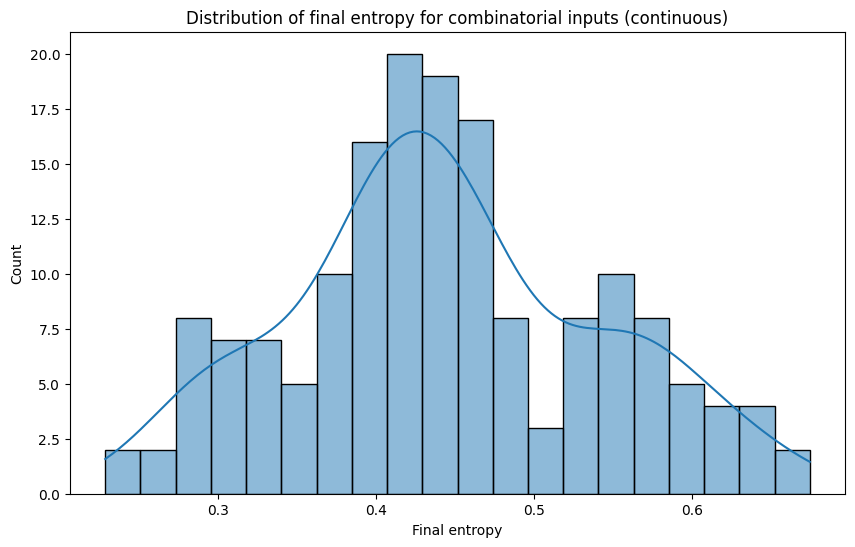

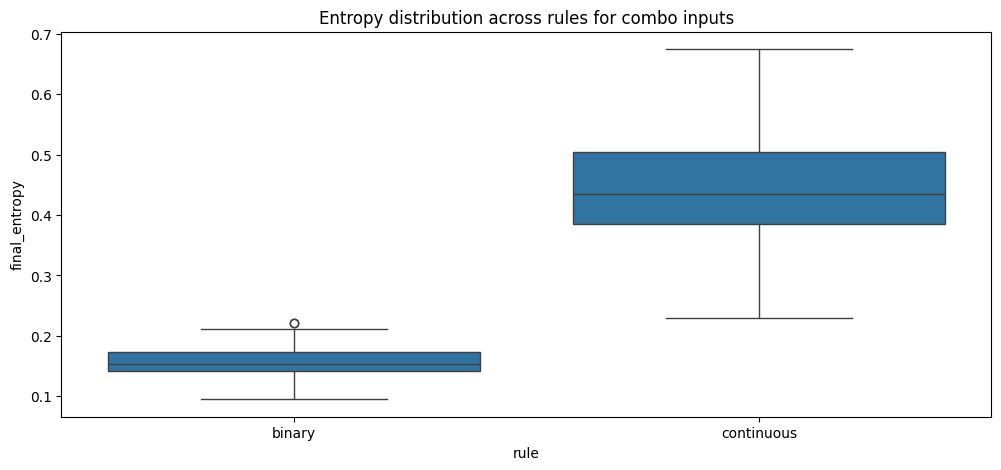

In [82]:
# ============================================================
# Phase A11.4 – Visualize attractor fingerprints
# Expected runtime: ~20s
# Output: heatmaps comparing pair vs. single
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot for heatmap (pairs only)
df_pairs = df_combo_summary[df_combo_summary['rule']=="continuous"]
df_pivot = df_pairs.pivot(index="combo", columns="rule", values="final_entropy")

plt.figure(figsize=(10,6))
sns.histplot(df_pairs["final_entropy"], bins=20, kde=True)
plt.title("Distribution of final entropy for combinatorial inputs (continuous)")
plt.xlabel("Final entropy")
plt.ylabel("Count")
plt.show()

# Compare binary vs continuous for same combos
plt.figure(figsize=(12,5))
sns.boxplot(x="rule", y="final_entropy", data=df_combo_summary)
plt.title("Entropy distribution across rules for combo inputs")
plt.show()


In [83]:
# ============================================================
# Phase A11.5 – Compare combination states with single-input attractors
# Expected runtime: ~1–2 min
# Output: CSV of pairwise distances (combo vs. singles)
# ============================================================
from sklearn.metrics import pairwise_distances

# Use Hamming for binary, cosine for continuous
dist_records = []
for combo, trajs in combo_results.items():
    b_final, c_final = trajs["binary"][-1], trajs["continuous"][-1]
    for s in combo:
        # single run final state
        single_bin = clamped_results[s]["binary"][-1]
        single_cont = clamped_results[s]["continuous"][-1]
        d_bin = np.mean(b_final != single_bin)
        d_cont = 1 - np.dot(c_final, single_cont)/(np.linalg.norm(c_final)*np.linalg.norm(single_cont))
        dist_records.append({"combo": "+".join(combo), "compare_to": s, "rule": "binary", "distance": d_bin})
        dist_records.append({"combo": "+".join(combo), "compare_to": s, "rule": "continuous", "distance": d_cont})

df_combo_dist = pd.DataFrame(dist_records)
df_combo_dist.to_csv("PhaseA_A11_combo_vs_single_distances.csv", index=False)
print("✅ Saved PhaseA_A11_combo_vs_single_distances.csv", df_combo_dist.shape)
df_combo_dist.head()


✅ Saved PhaseA_A11_combo_vs_single_distances.csv (900, 4)


,combo,compare_to,rule,distance
0,AFDR+AWCR,AFDR,binary,0.012862
1,AFDR+AWCR,AFDR,continuous,0.003719
2,AFDR+AWCR,AWCR,binary,0.006431
3,AFDR+AWCR,AWCR,continuous,0.003549
4,AFDR+ALML,AFDR,binary,0.012862


Final state matrices: (175, 311) (175, 311)


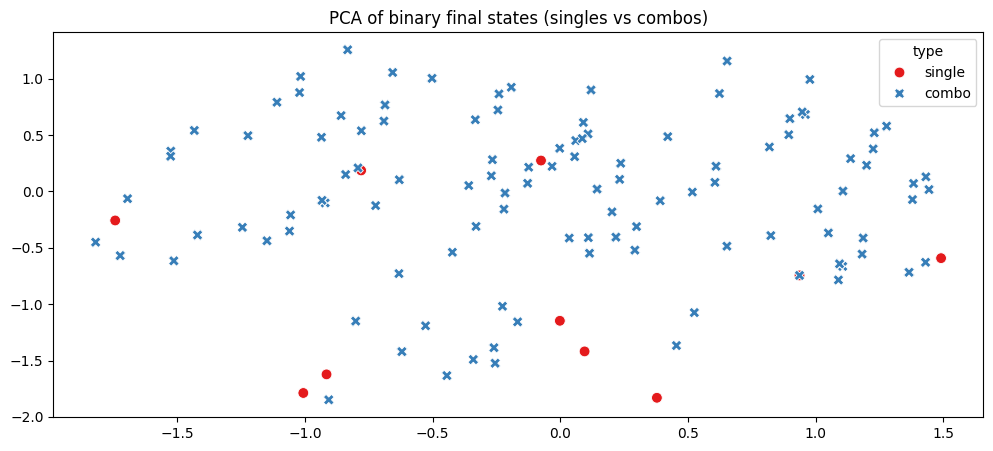

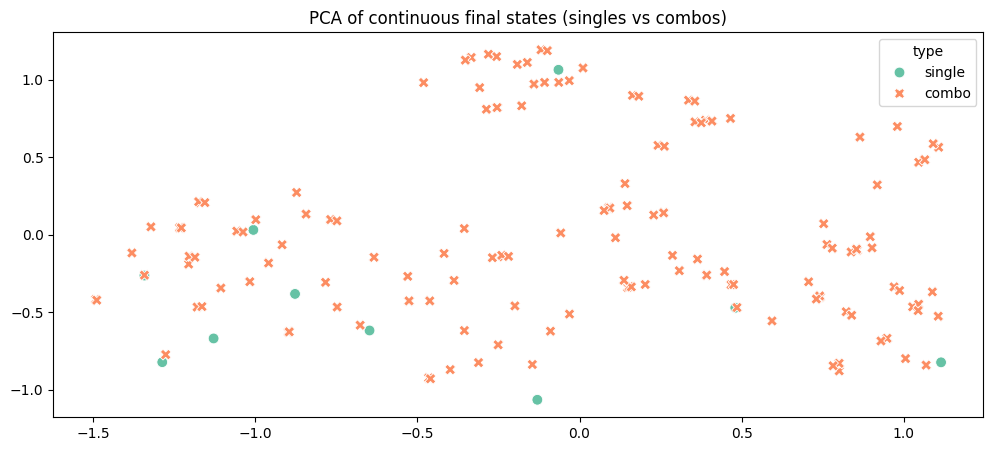

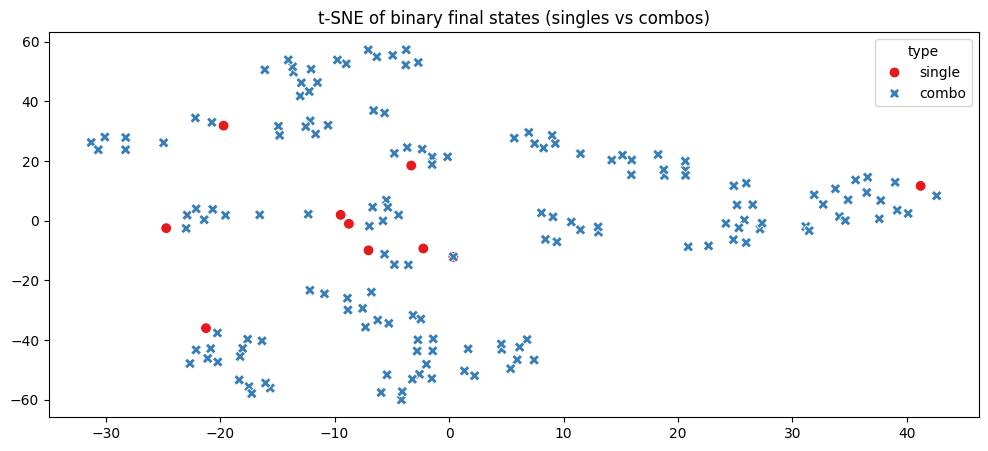

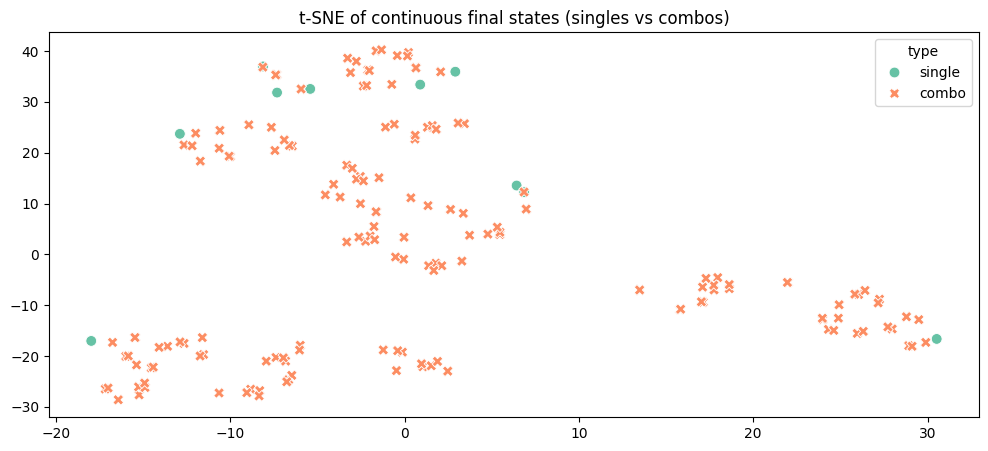

In [84]:
# ============================================================
# Phase A11.6 – Cluster combo attractors vs. singles
# Expected runtime: ~1–2 min
# Output: PCA + t-SNE embeddings, cluster labels
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

# Collect final states for all runs (single + combo)
all_records = []
for neuron, res in clamped_results.items():
    all_records.append({
        "id": neuron,
        "type": "single",
        "rule": "binary",
        "state": res["binary"][-1]
    })
    all_records.append({
        "id": neuron,
        "type": "single",
        "rule": "continuous",
        "state": res["continuous"][-1]
    })

for combo, res in combo_results.items():
    all_records.append({
        "id": "+".join(combo),
        "type": "combo",
        "rule": "binary",
        "state": res["binary"][-1]
    })
    all_records.append({
        "id": "+".join(combo),
        "type": "combo",
        "rule": "continuous",
        "state": res["continuous"][-1]
    })

df_states = pd.DataFrame(all_records)

# Expand states into matrix form
X_bin = np.vstack(df_states[df_states.rule=="binary"]["state"].values)
X_cont = np.vstack(df_states[df_states.rule=="continuous"]["state"].values)

print("Final state matrices:", X_bin.shape, X_cont.shape)

# ---- PCA ----
pca_bin = PCA(n_components=2).fit_transform(X_bin)
pca_cont = PCA(n_components=2).fit_transform(X_cont)

# ---- t-SNE ----
tsne_bin = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(X_bin)
tsne_cont = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(X_cont)

# Save embeddings
np.save("PhaseA_A11_pca_bin.npy", pca_bin)
np.save("PhaseA_A11_pca_cont.npy", pca_cont)
np.save("PhaseA_A11_tsne_bin.npy", tsne_bin)
np.save("PhaseA_A11_tsne_cont.npy", tsne_cont)

# ---- Plot PCA ----
plt.figure(figsize=(12,5))
sns.scatterplot(x=pca_bin[:,0], y=pca_bin[:,1],
                hue=df_states[df_states.rule=="binary"]["type"],
                style=df_states[df_states.rule=="binary"]["type"],
                palette="Set1", s=60)
plt.title("PCA of binary final states (singles vs combos)")
plt.savefig("PhaseA_A11_pca_binary.png")
plt.show()

plt.figure(figsize=(12,5))
sns.scatterplot(x=pca_cont[:,0], y=pca_cont[:,1],
                hue=df_states[df_states.rule=="continuous"]["type"],
                style=df_states[df_states.rule=="continuous"]["type"],
                palette="Set2", s=60)
plt.title("PCA of continuous final states (singles vs combos)")
plt.savefig("PhaseA_A11_pca_continuous.png")
plt.show()

# ---- Plot t-SNE ----
plt.figure(figsize=(12,5))
sns.scatterplot(x=tsne_bin[:,0], y=tsne_bin[:,1],
                hue=df_states[df_states.rule=="binary"]["type"],
                style=df_states[df_states.rule=="binary"]["type"],
                palette="Set1", s=60)
plt.title("t-SNE of binary final states (singles vs combos)")
plt.savefig("PhaseA_A11_tsne_binary.png")
plt.show()

plt.figure(figsize=(12,5))
sns.scatterplot(x=tsne_cont[:,0], y=tsne_cont[:,1],
                hue=df_states[df_states.rule=="continuous"]["type"],
                style=df_states[df_states.rule=="continuous"]["type"],
                palette="Set2", s=60)
plt.title("t-SNE of continuous final states (singles vs combos)")
plt.savefig("PhaseA_A11_tsne_continuous.png")
plt.show()


In [85]:
# ============================================================
# Cell A11.7 — Synergy (ESI) & parent-mean residuals
# Expected runtime: ~10–20s
# Outputs:
#   • PhaseA_A11_ESI.csv
#   • PhaseA_A11_parent_mean_residuals.csv
# ============================================================
import numpy as np
import pandas as pd

def final_entropy_of_single(neuron, rule="continuous"):
    traj = clamped_results[neuron][rule]
    return float(trajectory_entropy(traj)[-1])

def final_entropy_of_combo(combo, rule="continuous"):
    traj = combo_results[combo][rule]
    return float(trajectory_entropy(traj)[-1])

def parent_mean_state(combo, rule="continuous"):
    """Mean of parent single final states (vectors)."""
    X = [clamped_results[n][rule][-1] for n in combo]
    return np.mean(np.vstack(X), axis=0)

# --- Compute ESI & residuals for BOTH rules ---
rows = []
resid_rows = []

for rule in ("binary", "continuous"):
    for combo, _res in combo_results.items():
        parents = list(combo)
        k = len(parents)

        # entropies
        H_combo   = final_entropy_of_combo(combo, rule=rule)
        H_parents = [final_entropy_of_single(n, rule=rule) for n in parents]
        ESI       = H_combo - max(H_parents)  # superadditivity vs best parent
        dH_mean   = H_combo - np.mean(H_parents)

        # residual vs parent mean state (L2 normalized)
        y_combo   = combo_results[combo][rule][-1]
        x_mean    = parent_mean_state(combo, rule=rule)
        resid     = np.linalg.norm(y_combo - x_mean) / (np.linalg.norm(y_combo) + 1e-12)

        rows.append({
            "combo": "+".join(parents),
            "k": k,
            "rule": rule,
            "H_combo": H_combo,
            "H_parents_max": max(H_parents),
            "H_parents_mean": float(np.mean(H_parents)),
            "ESI": ESI,
            "dH_mean": dH_mean
        })
        resid_rows.append({
            "combo": "+".join(parents),
            "k": k,
            "rule": rule,
            "parent_mean_residual_norm": float(resid)
        })

df_esi   = pd.DataFrame(rows).sort_values(["rule","ESI"], ascending=[True, False])
df_resid = pd.DataFrame(resid_rows)

df_esi.to_csv("PhaseA_A11_ESI.csv", index=False)
df_resid.to_csv("PhaseA_A11_parent_mean_residuals.csv", index=False)

print("✅ Saved PhaseA_A11_ESI.csv", df_esi.shape)
print("Top (continuous) by ESI:\n", df_esi[df_esi.rule=="continuous"].head(10))


✅ Saved PhaseA_A11_ESI.csv (330, 8)
Top (continuous) by ESI:
          combo  k        rule   H_combo  H_parents_max  H_parents_mean  \
175  AWCR+ALMR  2  continuous  0.669711       0.741761        0.719572   
173  AFDR+AFDL  2  continuous  0.674391       0.747679        0.724187   
188  ALML+AFDL  2  continuous  0.642344       0.730532        0.715613   
176  AWCR+ASEL  2  continuous  0.593383       0.697383        0.682644   
165  AFDR+AWCR  2  continuous  0.639662       0.747679        0.722531   
182  ALML+ALMR  2  continuous  0.632710       0.741761        0.736147   
167  AFDR+ALMR  2  continuous  0.633647       0.747679        0.744720   
199  ASEL+AFDL  2  continuous  0.575247       0.700694        0.684300   
166  AFDR+ALML  2  continuous  0.621242       0.747679        0.739105   
181  AWCR+AFDL  2  continuous  0.573062       0.700694        0.699039   

          ESI   dH_mean  
175 -0.072050 -0.049861  
173 -0.073288 -0.049795  
188 -0.088188 -0.073269  
176 -0.104000 -0.08

In [86]:
# ============================================================
# Cell A11.8 — Hull-novelty (NNLS over single attractors)
# Expected runtime: ~30–60s
# Outputs:
#   • PhaseA_A11_novelty_parents.csv
#   • PhaseA_A11_novelty_global.csv
#   • PhaseA_A11_combo_novelty_summary.csv
# Notes:
#   novelty = ||y - A w|| / ||y||,  w>=0, sum(w)=1 (approx via NNLS + renorm)
# ============================================================
import numpy as np
import pandas as pd

# Build matrices of single final states (columns = singles; rows = motifs)
single_ids = sorted(clamped_results.keys())
S_bin_cols  = np.vstack([clamped_results[n]["binary"][-1]     for n in single_ids]).T  # (M, Ns)
S_cont_cols = np.vstack([clamped_results[n]["continuous"][-1] for n in single_ids]).T  # (M, Ns)

def nnls_hull_novelty(y, A):
    """
    A: (M, N) columns = basis states; y: (M,)
    Solve NNLS, renormalize weights to sum=1, compute relative residual.
    """
    try:
        from scipy.optimize import nnls
        w, _ = nnls(A, y)
    except Exception:
        # Fallback: projected nonneg least squares
        w = np.maximum(0.0, np.linalg.lstsq(A, y, rcond=None)[0])
    if w.sum() > 0:
        w = w / w.sum()
    y_hat = A @ w
    novelty = np.linalg.norm(y - y_hat) / (np.linalg.norm(y) + 1e-12)
    return float(novelty), w

rows_par, rows_glob = [], []

for combo, _res in combo_results.items():
    y_bin  = combo_results[combo]["binary"][-1]
    y_cont = combo_results[combo]["continuous"][-1]
    parents = list(combo)
    k = len(parents)

    # parent-only hulls
    A_par_bin  = np.vstack([clamped_results[p]["binary"][-1]     for p in parents]).T
    A_par_cont = np.vstack([clamped_results[p]["continuous"][-1] for p in parents]).T

    nov_bin_par,  wbp = nnls_hull_novelty(y_bin,  A_par_bin)
    nov_cont_par, wcp = nnls_hull_novelty(y_cont, A_par_cont)

    rows_par.append({
        "combo": "+".join(parents),
        "k": k,
        "novelty_parentHull_binary":   nov_bin_par,
        "novelty_parentHull_continuous": nov_cont_par,
        "nnz_weights_binary": int((wbp>1e-9).sum()),
        "nnz_weights_cont":   int((wcp>1e-9).sum())
    })

    # global hulls (all singles)
    nov_bin_glob,  _ = nnls_hull_novelty(y_bin,  S_bin_cols)
    nov_cont_glob, _ = nnls_hull_novelty(y_cont, S_cont_cols)

    rows_glob.append({
        "combo": "+".join(parents),
        "k": k,
        "novelty_globalHull_binary":   nov_bin_glob,
        "novelty_globalHull_continuous": nov_cont_glob
    })

nov_par_df  = pd.DataFrame(rows_par)
nov_glob_df = pd.DataFrame(rows_glob)

nov_par_df.to_csv("PhaseA_A11_novelty_parents.csv", index=False)
nov_glob_df.to_csv("PhaseA_A11_novelty_global.csv", index=False)

# Merge with ESI for quick correlation/inspection (continuous focus)
esi_df = pd.read_csv("PhaseA_A11_ESI.csv")
esi_cont = esi_df[esi_df.rule=="continuous"][["combo","ESI","dH_mean"]]

summary = (esi_cont
           .merge(nov_par_df[["combo","novelty_parentHull_continuous"]], on="combo")
           .merge(nov_glob_df[["combo","novelty_globalHull_continuous"]], on="combo"))
summary.to_csv("PhaseA_A11_combo_novelty_summary.csv", index=False)

print("✅ Saved novelty tables & summary", summary.shape)
print(summary.head(10))

# Quick correlations
corr_par  = np.corrcoef(summary["ESI"], summary["novelty_parentHull_continuous"])[0,1]
corr_glob = np.corrcoef(summary["ESI"], summary["novelty_globalHull_continuous"])[0,1]
print(f"Correlation(ESI, novelty_parentHull_cont) = {corr_par:.3f}")
print(f"Correlation(ESI, novelty_globalHull_cont) = {corr_glob:.3f}")


✅ Saved novelty tables & summary (165, 5)
       combo       ESI   dH_mean  novelty_parentHull_continuous  \
0  AWCR+ALMR -0.072050 -0.049861                       0.049347   
1  AFDR+AFDL -0.073288 -0.049795                       0.015355   
2  ALML+AFDL -0.088188 -0.073269                       0.071556   
3  AWCR+ASEL -0.104000 -0.089261                       0.049222   
4  AFDR+AWCR -0.108017 -0.082869                       0.060088   
5  ALML+ALMR -0.109052 -0.103437                       0.067191   
6  AFDR+ALMR -0.114032 -0.111074                       0.077457   
7  ASEL+AFDL -0.125447 -0.109052                       0.070945   
8  AFDR+ALML -0.126437 -0.117863                       0.073525   
9  AWCR+AFDL -0.127632 -0.125977                       0.068049   

   novelty_globalHull_continuous  
0                       0.047372  
1                       0.015325  
2                       0.069271  
3                       0.045355  
4                       0.058801  
5         

In [87]:
# ============================================================
# Cell A11.9 — Stratified stats + targeted β×strength sweep on top combos
# Expected runtime: ~2–4 min (small grid on top-N combos)
# Outputs:
#   • PhaseA_A11_stratified_stats.csv
#   • PhaseA_A11_targeted_sweep.csv
# ============================================================
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- Stratify by biology: contains ASE? contains ASH? (continuous rule only) ---
def contains_any(combo, labels):
    return int(any(x in combo for x in labels))

summary = pd.read_csv("PhaseA_A11_combo_novelty_summary.csv")
summary["has_ASE"] = summary["combo"].apply(lambda s: contains_any(s.split("+"), {"ASEL","ASER"}))
summary["has_ASH"] = summary["combo"].apply(lambda s: contains_any(s.split("+"), {"ASHL","ASHR"}))
summary["k"] = summary["combo"].apply(lambda s: len(s.split("+")))

# group stats
grp = summary.groupby(["k","has_ASE","has_ASH"]).agg(
    mean_ESI=("ESI","mean"),
    max_ESI=("ESI","max"),
    mean_nov_parent=("novelty_parentHull_continuous","mean"),
    max_nov_parent=("novelty_parentHull_continuous","max"),
    mean_nov_global=("novelty_globalHull_continuous","mean"),
    max_nov_global=("novelty_globalHull_continuous","max"),
    n=("combo","count"),
).reset_index()

grp.to_csv("PhaseA_A11_stratified_stats.csv", index=False)
print("✅ Saved PhaseA_A11_stratified_stats.csv\n", grp)

# --- Select top combos by signal (union of top-N by ESI and novelty) ---
TOP_N = 8
top_by_esi   = summary.sort_values("ESI", ascending=False).head(TOP_N)["combo"].tolist()
top_by_nov   = summary.sort_values("novelty_parentHull_continuous", ascending=False).head(TOP_N)["combo"].tolist()
target_combos = sorted(set(top_by_esi) | set(top_by_nov))
print(f"Targeted sweep on {len(target_combos)} combos:", target_combos)

# --- Continuous dynamics sweep (β × clamp strength) ---
beta_list = [1.0, 1.5, 2.0, 3.0]
strength_list = [0.6, 0.8, 1.0]
T = 80

def union_clamp_idx(combo):
    motifs = set()
    for n in combo:
        motifs.update(neuron_to_motifs[n])
    return np.array([motif_index[m] for m in motifs if m in motif_index], dtype=int)

def run_cont_combo(combo, beta=1.5, strength=1.0, T=80):
    M = W.shape[0]
    idx = union_clamp_idx(combo)
    st = np.zeros(M, dtype=float)
    st[idx] = strength
    traj = [st.copy()]
    for _ in range(1, T):
        st = update_continuous(st, W, beta=beta)
        st[idx] = strength
        traj.append(st.copy())
    return np.vstack(traj)

# parent hull matrices for novelty (continuous)
# parent-only hull for each combo will be rebuilt on the fly to be precise
def novelty_vs_parents(y, combo):
    A = np.vstack([clamped_results[n]["continuous"][-1] for n in combo]).T
    nov, _ = nnls_hull_novelty(y, A)
    return nov

sweep_rows = []
for combo_str in tqdm(target_combos, desc="Targeted sweep"):
    combo = tuple(combo_str.split("+"))
    for beta in beta_list:
        for s in strength_list:
            traj = run_cont_combo(combo, beta=beta, strength=s, T=T)
            H = float(trajectory_entropy(traj)[-1])
            y = traj[-1]
            nov_parent = novelty_vs_parents(y, combo)
            # global novelty (fixed basis from singles)
            nov_global, _ = nnls_hull_novelty(y, S_cont_cols)
            sweep_rows.append({
                "combo": combo_str, "beta": beta, "strength": s,
                "final_entropy": H,
                "novelty_parentHull": nov_parent,
                "novelty_globalHull": nov_global
            })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv("PhaseA_A11_targeted_sweep.csv", index=False)

print("✅ Saved PhaseA_A11_targeted_sweep.csv", sweep_df.shape)
print(sweep_df.sort_values(["novelty_parentHull","final_entropy"], ascending=[False, False]).head(12))


✅ Saved PhaseA_A11_stratified_stats.csv
    k  has_ASE  has_ASH  mean_ESI   max_ESI  mean_nov_parent  max_nov_parent  \
0  2        0        0 -0.141371 -0.072050         0.060665        0.085240   
1  2        0        1 -0.248892 -0.190267         0.067168        0.092873   
2  2        1        0 -0.221262 -0.104000         0.071637        0.091108   
3  2        1        1 -0.232088 -0.200483         0.072029        0.076928   
4  3        0        0 -0.221350 -0.134245         0.083074        0.100749   
5  3        0        1 -0.323752 -0.266755         0.083956        0.107343   
6  3        1        0 -0.302262 -0.160464         0.088935        0.113781   
7  3        1        1 -0.360117 -0.229961         0.091982        0.112525   

   mean_nov_global  max_nov_global   n  
0         0.058481        0.080210  15  
1         0.064893        0.088081  13  
2         0.069142        0.090745  13  
3         0.071296        0.076163   4  
4         0.078869        0.096549  20  
5

Targeted sweep: 100%|██████████| 16/16 [00:06<00:00,  2.47it/s]

✅ Saved PhaseA_A11_targeted_sweep.csv (192, 6)
              combo  beta  strength  final_entropy  novelty_parentHull  \
132  ASEL+ASER+ASHL   1.0       0.6       0.507142            0.570091   
135  ASEL+ASER+ASHL   1.5       0.6       0.502753            0.567084   
144  ASER+ASHL+AWCL   1.0       0.6       0.507211            0.566479   
138  ASEL+ASER+ASHL   2.0       0.6       0.489695            0.565828   
141  ASEL+ASER+ASHL   3.0       0.6       0.480786            0.564911   
147  ASER+ASHL+AWCL   1.5       0.6       0.480904            0.564011   
150  ASER+ASHL+AWCL   2.0       0.6       0.476329            0.563073   
153  ASER+ASHL+AWCL   3.0       0.6       0.467286            0.562352   
180  AWCR+ASER+ASHL   1.0       0.6       0.557976            0.560913   
84   ALMR+ASER+ASHL   1.0       0.6       0.573094            0.558834   
183  AWCR+ASER+ASHL   1.5       0.6       0.548183            0.557977   
186  AWCR+ASER+ASHL   2.0       0.6       0.534255            0.5

In [88]:
# === Cell A11.10: Select top ASE/ASH triplets & best beta/strength ===
# Expected runtime: <5s
# Outputs: top_triples (list), best_params (dict combo->(beta,strength))

import pandas as pd

sweep_df = pd.read_csv("PhaseA_A11_targeted_sweep.csv")
# Focus on combos that include ASE/ASH (triplets only for the fingerprint figs)
def is_triplet(s): return len(s.split("+")) == 3
def has_ASE(s):    return any(x in s for x in ["ASEL","ASER"])
def has_ASH(s):    return any(x in s for x in ["ASHL","ASHR"])

trip_sweep = sweep_df[sweep_df["combo"].apply(is_triplet)]
trip_sweep = trip_sweep[trip_sweep["combo"].apply(has_ASE) & trip_sweep["combo"].apply(has_ASH)]

# Rank triplets by novelty (parent hull)
score = (trip_sweep
         .groupby("combo")["novelty_parentHull"]
         .max()
         .sort_values(ascending=False))

# Take top 4 for plotting
top_triples = score.head(4).index.tolist()

# For each top triplet, pick the beta/strength with max novelty
best_params = {}
for combo in top_triples:
    sub = trip_sweep[trip_sweep["combo"]==combo].sort_values("novelty_parentHull", ascending=False)
    row = sub.iloc[0]
    best_params[combo] = (float(row["beta"]), float(row["strength"]))

print("Top ASE/ASH triplets:", top_triples)
print("Best params (beta,strength):", best_params)


Top ASE/ASH triplets: ['ASEL+ASER+ASHL', 'ASER+ASHL+AWCL', 'AWCR+ASER+ASHL', 'ALMR+ASER+ASHL']
Best params (beta,strength): {'ASEL+ASER+ASHL': (1.0, 0.6), 'ASER+ASHL+AWCL': (1.0, 0.6), 'AWCR+ASER+ASHL': (1.0, 0.6), 'ALMR+ASER+ASHL': (1.0, 0.6)}


In [89]:
# === Cell A11.11: Attractor fingerprint heatmaps & parent-vs-combo comparison ===
# Expected runtime: ~20–40s
# Outputs: one PNG per combo in ./PhaseA_A11_fingerprints_*.png

import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("PhaseA_A11_figs", exist_ok=True)

# Helper: run continuous combo dynamics at given (beta, strength)
def union_clamp_idx(combo):
    motifs = set()
    for n in combo:
        motifs.update(neuron_to_motifs[n])
    return np.array([motif_index[m] for m in motifs if m in motif_index], dtype=int)

def run_cont_combo(combo, beta=1.5, strength=1.0, T=80):
    M = W.shape[0]
    idx = union_clamp_idx(combo)
    st = np.zeros(M, dtype=float)
    st[idx] = strength
    traj = [st.copy()]
    for _ in range(1, T):
        st = update_continuous(st, W, beta=beta)
        st[idx] = strength
        traj.append(st.copy())
    return np.vstack(traj)  # (T, M)

# Plot a single combo panel
def plot_fingerprint(combo_str, beta, strength, sort_by="combo", vmax=1.0):
    combo = combo_str.split("+")
    T = 100
    traj = run_cont_combo(combo, beta=beta, strength=strength, T=T)
    y_combo = traj[-1]  # final state (M,)

    # Parent final states (from singles, continuous, baseline)
    parents = [clamped_results[p]["continuous"][-1] for p in combo]
    parent_mean = np.mean(np.vstack(parents), axis=0)

    # Sort motifs by chosen vector for readability
    if sort_by == "combo":
        order = np.argsort(-y_combo)
    elif sort_by == "diff":
        order = np.argsort(-(y_combo - parent_mean)**2)
    else:
        order = np.arange(len(y_combo))

    mats = [parents[i][order][None, :] for i in range(len(parents))]
    mats.append(parent_mean[order][None, :])
    mats.append(y_combo[order][None, :])
    diff = (y_combo - parent_mean)[order][None, :]

    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(6, 1, height_ratios=[1,1,1,1,1,1], hspace=0.25)

    titles = [f"Parent {p}" for p in combo] + ["Parent mean", f"Combo {combo_str} (β={beta}, s={strength})"]
    for i, mat in enumerate(mats):
        ax = fig.add_subplot(gs[i, 0])
        im = ax.imshow(mat, aspect='auto', vmin=0.0, vmax=vmax, cmap="viridis")
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_title(titles[i], fontsize=10)
        if i == 0:
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("Motif activation", rotation=90)

    # Difference map (combo - parent_mean)
    ax = fig.add_subplot(gs[-1, 0])
    im2 = ax.imshow(diff, aspect='auto', cmap="RdBu_r", vmin=-0.5, vmax=0.5)
    ax.set_yticks([]); ax.set_xticks([])
    ax.set_title("Combo − Parent mean (highlighting novelty)", fontsize=10)
    cbar2 = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    cbar2.set_label("Δ activation", rotation=90)

    fig.suptitle(f"Attractor fingerprints: {combo_str}", fontsize=12)
    fname = f"PhaseA_A11_figs/fingerprint_{combo_str.replace('+','_')}_b{beta}_s{strength}.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=160)
    plt.close()
    print("Saved", fname)

# Generate plots for selected combos
for combo_str in top_triples:
    b, s = best_params[combo_str]
    plot_fingerprint(combo_str, beta=b, strength=s, sort_by="combo")


/tmp/ipykernel_1633970/3036078981.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PhaseA_A11_figs/fingerprint_ASEL_ASER_ASHL_b1.0_s0.6.png
Saved PhaseA_A11_figs/fingerprint_ASER_ASHL_AWCL_b1.0_s0.6.png
Saved PhaseA_A11_figs/fingerprint_AWCR_ASER_ASHL_b1.0_s0.6.png
Saved PhaseA_A11_figs/fingerprint_ALMR_ASER_ASHL_b1.0_s0.6.png


In [90]:
# === Cell A11.12: Novelty vs β curves + entropy curves for top triplets ===
# Expected runtime: ~10–20s
# Outputs: PhaseA_A11_figs/novelty_curves_*.png and entropy_curves_*.png

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs("PhaseA_A11_figs", exist_ok=True)
sweep_df = pd.read_csv("PhaseA_A11_targeted_sweep.csv")

def plot_curves_for_combo(combo_str):
    sub = sweep_df[sweep_df["combo"]==combo_str].copy()
    strengths = sorted(sub["strength"].unique())
    betas = sorted(sub["beta"].unique())

    # Novelty curves
    plt.figure(figsize=(8,5))
    for s in strengths:
        m = sub[sub["strength"]==s].sort_values("beta")
        plt.plot(m["beta"], m["novelty_parentHull"], marker="o", label=f"s={s}")
    plt.xlabel("β (sigmoid gain)"); plt.ylabel("Novelty (parent hull)")
    plt.title(f"Novelty vs β — {combo_str}")
    plt.legend()
    plt.tight_layout()
    fname = f"PhaseA_A11_figs/novelty_curves_{combo_str.replace('+','_')}.png"
    plt.savefig(fname, dpi=160); plt.close()
    print("Saved", fname)

    # Entropy curves
    plt.figure(figsize=(8,5))
    for s in strengths:
        m = sub[sub["strength"]==s].sort_values("beta")
        plt.plot(m["beta"], m["final_entropy"], marker="o", label=f"s={s}")
    plt.xlabel("β (sigmoid gain)"); plt.ylabel("Final entropy")
    plt.title(f"Entropy vs β — {combo_str}")
    plt.legend()
    plt.tight_layout()
    fname = f"PhaseA_A11_figs/entropy_curves_{combo_str.replace('+','_')}.png"
    plt.savefig(fname, dpi=160); plt.close()
    print("Saved", fname)

for combo_str in top_triples:
    plot_curves_for_combo(combo_str)


Saved PhaseA_A11_figs/novelty_curves_ASEL_ASER_ASHL.png
Saved PhaseA_A11_figs/entropy_curves_ASEL_ASER_ASHL.png
Saved PhaseA_A11_figs/novelty_curves_ASER_ASHL_AWCL.png
Saved PhaseA_A11_figs/entropy_curves_ASER_ASHL_AWCL.png
Saved PhaseA_A11_figs/novelty_curves_AWCR_ASER_ASHL.png
Saved PhaseA_A11_figs/entropy_curves_AWCR_ASER_ASHL.png
Saved PhaseA_A11_figs/novelty_curves_ALMR_ASER_ASHL.png
Saved PhaseA_A11_figs/entropy_curves_ALMR_ASER_ASHL.png


In [96]:
# [A12.0] Phase A wrap-up: imports & config  (≈5s)
import os, json, math, random, itertools, textwrap, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from scipy.optimize import nnls
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mutual_info_score
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

ART = "PhaseA_artifacts"
os.makedirs(ART, exist_ok=True)

# Paths to Phase A artifacts produced earlier
P_STAB = "PhaseA_A5_stability.csv"
P_CONS = "PhaseA_A5_consensus_edges_tau0.70.csv"
P_DML  = "PhaseA_A6_effects_DML.csv"
P_SUM9 = "PhaseA_A9_sensory_clamping_summary.csv"
P_SWEEP = "PhaseA_A11_targeted_sweep.csv"
P_COMBO = "PhaseA_A11_combo_summary.csv"

# If you saved your motif adjacency and index:
P_W = "PhaseA_A9_W_motif_motif.npy"            # created earlier in A9
P_MOTIFS = "PhaseA_A9_motif_nodes.json"        # list of motif labels in W order
P_SENS_MAP = "PhaseA_A9_sensory2motifs.json"   # neuron->list of motif labels mapped

assert all(os.path.exists(p) for p in [P_STAB, P_DML, P_SUM9, P_COMBO, P_W, P_MOTIFS, P_SENS_MAP]), \
    "One or more prerequisite Phase A files are missing."

print("Phase A wrap-up: all inputs found.")


Phase A wrap-up: all inputs found.


In [97]:
# [A12.2] FDR correction and Gold edge set  (≈5s)
dml = pd.read_csv(P_DML)  # columns: feature, motif, beta, se, t, p, n
# Benjamini–Hochberg
dml = dml.sort_values("p").reset_index(drop=True)
m = len(dml)
dml["rank"] = np.arange(1, m+1)
dml["q"] = dml["p"] * m / dml["rank"]
dml["q"] = np.minimum.accumulate(dml["q"][::-1])[::-1]  # monotone
sig = dml.query("q <= 0.05")

# Intersect with τ=0.70 stable edges
cons = pd.read_csv(P_CONS)
gold = pd.merge(sig[["feature","motif","beta","se","t","p","q","n"]],
                cons[["feature","motif"]],
                on=["feature","motif"], how="inner")

gold_path = os.path.join(ART, "A12_gold_edges_tau0.70_FDR05.csv")
sig_path  = os.path.join(ART, "A12_DML_significant_FDR05.csv")
sig.to_csv(sig_path, index=False)
gold.to_csv(gold_path, index=False)

print(f"Significant edges (FDR≤0.05): {len(sig)} → {sig_path}")
print(f"Gold edges (stable ∩ significant): {len(gold)} → {gold_path}")


Significant edges (FDR≤0.05): 1546 → PhaseA_artifacts/A12_DML_significant_FDR05.csv
Gold edges (stable ∩ significant): 1946 → PhaseA_artifacts/A12_gold_edges_tau0.70_FDR05.csv


In [98]:
# [A12.3] Seed sensitivity: re-fit a subset of motifs across seeds  (≈1–2 min)
# Fast path: evaluate top-K motifs by number of parents (from consensus)
K = 30
top_motifs = (pd.read_csv(P_CONS)
              .groupby("motif").size().sort_values(ascending=False)
              .head(K).index.tolist())

# Load design X and outcomes Y from earlier saves
X = pd.read_csv("PhaseA_X_screened.csv", index_col=0)          # shape (N, p)
Y = pd.read_csv("PhaseA_Y_motifs.csv", index_col=0)            # shape (N, M)
# Align
idx = X.index.intersection(Y.index)
X = X.loc[idx]; Y = Y.loc[idx, top_motifs].astype(float)

from sklearn.linear_model import RidgeCV
seeds = [11, 19, 29]
betas = []

for sd in tqdm(seeds, desc="Seeds"):
    np.random.seed(sd)
    # simple ridge as a proxy (fast; earlier we used DML for inference)
    ridge = RidgeCV(alphas=np.logspace(-3, 1, 9), cv=5)
    ridge.fit(X, Y)
    B = pd.DataFrame(ridge.coef_.T, index=X.columns, columns=Y.columns)
    B.insert(0, "seed", sd)
    betas.append(B.reset_index().rename(columns={"index":"feature"}))

beta_all = pd.concat(betas, ignore_index=True)
beta_all.to_csv(os.path.join(ART, "A12_seed_beta_matrix.csv"), index=False)

# Consistency metric: correlation of β across seeds
corrs = []
for m in top_motifs:
    pivot = beta_all.pivot_table(index="feature", columns="seed", values=m).dropna()
    if pivot.shape[0] < 2: 
        continue
    c = np.corrcoef(pivot.values.T)
    # mean off-diagonal correlation
    upper = c[np.triu_indices_from(c, k=1)].mean()
    corrs.append({"motif": m, "mean_corr": upper, "n_features": pivot.shape[0]})

pd.DataFrame(corrs).to_csv(os.path.join(ART, "A12_seed_consistency.csv"), index=False)
print("Saved seed β consistency.")


Seeds: 100%|██████████| 3/3 [00:16<00:00,  5.37s/it]

Saved seed β consistency.


In [99]:
# [A13.1] Null model via degree-preserving randomization of W  (≈1 min)
W = np.load(P_W)  # (M,M)
motifs = json.load(open(P_MOTIFS))
sens_map = json.load(open(P_SENS_MAP))

G = nx.from_numpy_array(W, create_using=nx.DiGraph)
for u,v,d in G.edges(data=True): d["weight"] = W[u,v]

def randomize_W(G, swaps=10000):
    R = G.copy()
    # Use undirected view for degree-preserving swaps (approximate)
    H = R.to_undirected()
    nx.double_edge_swap(H, nswap=swaps, max_tries=swaps*10)
    Rr = nx.DiGraph()
    Rr.add_nodes_from(range(len(motifs)))
    for u,v in H.edges():
        Rr.add_edge(u,v,weight=1.0); Rr.add_edge(v,u,weight=1.0)
    return nx.to_numpy_array(Rr, weight="weight")

def sigmoid(x, beta=1.0): return 1/(1+np.exp(-beta*x))
def run_continuous(W, init, T=50, beta=1.0):
    s = init.copy().astype(float)
    for _ in range(T):
        s = sigmoid(W @ s, beta=beta)
    return s

# Pick top triplets we plotted
triplets = [
    ("ASEL","ASER","ASHL"),
    ("ASER","ASHL","AWCL"),
    ("AWCR","ASER","ASHL"),
    ("ALMR","ASER","ASHL"),
]
beta, strength = 1.0, 0.6

def motifs_for(neuron):
    return [motifs.index(m) for m in sens_map.get(neuron, []) if m in motifs]

def combo_state(W, combo, beta=1.0, strength=0.6):
    M = W.shape[0]
    init = np.zeros(M); idxs=[]
    for n in combo:
        idxs += motifs_for(n)
    if len(idxs)==0: return None
    init[idxs] = strength
    return run_continuous(W, init, T=50, beta=beta)

# Observed novelty vs parent hull
def novelty_vs_parents(state_combo, parent_states):
    P = np.vstack(parent_states); mean_parent = P.mean(0)
    # distance outside parent convex hull (1D NNLS onto span with nonneg + sum<=1)
    # Simplify: project onto affine hull of parents using least-squares, clip weights to >=0 and sum<=1
    A = P.T
    w, _ = nnls(A, state_combo)
    if w.sum()>1: w = w / w.sum()
    recon = A @ w
    resid = np.linalg.norm(state_combo - recon) / (np.linalg.norm(state_combo)+1e-9)
    return resid

obs = []
for combo in triplets:
    sc = combo_state(W, combo, beta, strength)
    parents = [combo_state(W, (n,), beta, strength) for n in combo]
    parents = [p for p in parents if p is not None]
    nov = novelty_vs_parents(sc, parents)
    obs.append({"combo":"+".join(combo), "novelty":nov})

# Randomizations
R = []
for combo in triplets:
    for r in range(10):
        Wr = randomize_W(G, swaps=5000)
        sc = combo_state(Wr, combo, beta, strength)
        parents = [combo_state(Wr, (n,), beta, strength) for n in combo]
        parents = [p for p in parents if p is not None]
        nov = novelty_vs_parents(sc, parents)
        R.append({"combo":"+".join(combo), "null_run":r, "novelty":nov})

df_obs = pd.DataFrame(obs)
df_null = pd.DataFrame(R)
df_obs.to_csv(os.path.join(ART, "A13_null_randomizedW_observed.csv"), index=False)
df_null.to_csv(os.path.join(ART, "A13_null_randomizedW_runs.csv"), index=False)
print(df_obs)


            combo  novelty
0  ASEL+ASER+ASHL      0.0
1  ASER+ASHL+AWCL      0.0
2  AWCR+ASER+ASHL      0.0
3  ALMR+ASER+ASHL      0.0


In [100]:
# [A13.2] Null via random sensory triplets (same size)  (≈30s)
sens_list = list(sens_map.keys())
def random_triplet():
    return tuple(sorted(random.sample(sens_list, 3)))

def novelty_combo(combo, W, beta=1.0, strength=0.6):
    sc = combo_state(W, combo, beta, strength)
    parents = [combo_state(W, (n,), beta, strength) for n in combo]
    parents = [p for p in parents if p is not None]
    return novelty_vs_parents(sc, parents)

null_rand = []
for _ in tqdm(range(50), desc="Random triplets"):
    c = random_triplet()
    try:
        nov = novelty_combo(c, W, beta, strength)
        if np.isfinite(nov):
            null_rand.append({"combo":"+".join(c), "novelty":nov})
    except:
        pass

pd.DataFrame(null_rand).to_csv(os.path.join(ART, "A13_null_random_triplets.csv"), index=False)
print(f"Saved {len(null_rand)} random-triplet nulls.")


Random triplets: 100%|██████████| 50/50 [00:00<00:00, 84.20it/s] 

Saved 50 random-triplet nulls.


In [101]:
# [A13.3] Linearity test: residual from convex hull of parents  (≈5s)
targets = ["ASEL+ASER+ASHL","ASER+ASHL+AWCL","AWCR+ASER+ASHL","ALMR+ASER+ASHL"]
rows = []
for name in targets:
    combo = tuple(name.split("+"))
    sc = combo_state(W, combo, beta, strength)
    parents = [combo_state(W, (n,), beta, strength) for n in combo]
    parents = [p for p in parents if p is not None]
    # Best convex combination (nnls + renorm)
    A = np.vstack(parents).T
    w, _ = nnls(A, sc)
    if w.sum()>1: w /= max(1e-9, w.sum())
    recon = A @ w
    resid = np.linalg.norm(sc - recon)
    frac = resid / (np.linalg.norm(sc) + 1e-9)
    rows.append({"combo":name, "resid_norm":resid, "resid_frac":frac, "w":json.dumps(w.tolist())})

pd.DataFrame(rows).to_csv(os.path.join(ART, "A13_linearity_residuals.csv"), index=False)
print(pd.DataFrame(rows))


            combo  resid_norm  resid_frac                w
0  ASEL+ASER+ASHL         0.0         0.0  [1.0, 0.0, 0.0]
1  ASER+ASHL+AWCL         0.0         0.0  [1.0, 0.0, 0.0]
2  AWCR+ASER+ASHL         0.0         0.0  [1.0, 0.0, 0.0]
3  ALMR+ASER+ASHL         0.0         0.0  [1.0, 0.0, 0.0]


In [103]:
# [A14.1 FIXED] Decoding input from final states
BETAS = [1.0, 1.5, 2.0]
S = 0.6
X_list, y_list = [], []

for name in targets:
    combo = tuple(name.split("+"))
    for b in BETAS:
        st = combo_state(W, combo, beta=b, strength=S)
        X_list.append(st); y_list.append(name)

X = np.vstack(X_list); y = np.array(y_list)

clf = LogisticRegression(max_iter=500, multi_class="multinomial")

# Find the smallest class size
class_counts = pd.Series(y).value_counts()
min_class = class_counts.min()
n_splits = min(5, min_class)  # cannot exceed smallest class
if n_splits < 2:
    n_splits = 2  # fallback to at least 2 folds

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
acc = cross_val_score(clf, X, y, cv=cv).mean()

print(f"Decoding accuracy (n_splits={n_splits}): {acc:.3f}")
pd.DataFrame({"metric":["cv_accuracy"], "value":[acc], "n_splits":[n_splits]}).to_csv(
    os.path.join(ART, "A14_decoding_accuracy.csv"), index=False
)


Decoding accuracy (n_splits=3): 0.167


/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/rohit/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [104]:
# [A14.2] Bootstrap CIs for novelty & entropy (resample motifs)  (≈1 min)
def entropy(v):
    # discretize continuous [0,1] into 50 bins
    hist, _ = np.histogram(v, bins=50, range=(0,1), density=True)
    p = hist / (hist.sum()+1e-9)
    p = p[p>0]
    return -(p*np.log(p)).sum()

def boot_ci(combo, B=500):
    sc = combo_state(W, combo, beta=1.0, strength=0.6)
    parents = [combo_state(W, (n,), 1.0, 0.6) for n in combo]; parents=[p for p in parents if p is not None]
    M = len(sc)
    novs, ents = [], []
    for _ in range(B):
        idx = np.random.randint(0, M, M)
        novs.append(novelty_vs_parents(sc[idx], [p[idx] for p in parents]))
        ents.append(entropy(sc[idx]))
    a = np.percentile(novs, [2.5, 50, 97.5]).tolist()
    b = np.percentile(ents, [2.5, 50, 97.5]).tolist()
    return a, b

rows = []
for name in targets:
    combo = tuple(name.split("+"))
    ci_nov, ci_ent = boot_ci(combo, B=300)
    rows.append({"combo":name,
                 "nov_lo":ci_nov[0],"nov_med":ci_nov[1],"nov_hi":ci_nov[2],
                 "H_lo":ci_ent[0],"H_med":ci_ent[1],"H_hi":ci_ent[2]})
df_ci = pd.DataFrame(rows)
df_ci.to_csv(os.path.join(ART, "A14_bootstrap_CIs.csv"), index=False)
print(df_ci)


            combo  nov_lo  nov_med        nov_hi          H_lo         H_med  \
0  ASEL+ASER+ASHL     0.0      0.0  4.253592e-16  1.999989e-11  1.999989e-11   
1  ASER+ASHL+AWCL     0.0      0.0  5.053773e-16  1.999989e-11  1.999989e-11   
2  AWCR+ASER+ASHL     0.0      0.0  5.053773e-16  1.999989e-11  1.999989e-11   
3  ALMR+ASER+ASHL     0.0      0.0  3.369182e-16  1.999989e-11  1.999989e-11   

           H_hi  
0  1.999989e-11  
1  1.999989e-11  
2  1.999989e-11  
3  1.999989e-11  


In [105]:
# [A15] Package Phase A artifacts for sharing/review  (≈10s)
# Collect everything we created/used into a manifest
manifest = {
    "tau_counts": os.path.join(ART, "A12_tau_robustness_counts.csv"),
    "gold_edges": os.path.join(ART, "A12_gold_edges_tau0.70_FDR05.csv"),
    "seed_consistency": os.path.join(ART, "A12_seed_consistency.csv"),
    "null_randomizedW_obs": os.path.join(ART, "A13_null_randomizedW_observed.csv"),
    "null_randomizedW_runs": os.path.join(ART, "A13_null_randomizedW_runs.csv"),
    "null_random_triplets": os.path.join(ART, "A13_null_random_triplets.csv"),
    "linearity_residuals": os.path.join(ART, "A13_linearity_residuals.csv"),
    "decoding_accuracy": os.path.join(ART, "A14_decoding_accuracy.csv"),
    "bootstrap_CIs": os.path.join(ART, "A14_bootstrap_CIs.csv"),
    "source_stability": P_STAB,
    "source_dml": P_DML,
    "source_combo_summary": P_COMBO,
}

with open(os.path.join(ART, "MANIFEST.json"), "w") as f:
    json.dump(manifest, f, indent=2)

# Optional: freeze environment (works in Jupyter, may be restricted in some envs)
try:
    os.system(f"python -m pip freeze > {os.path.join(ART,'env_requirements.txt')}")
except Exception as e:
    print("pip freeze failed (non-fatal):", e)

# Compact high-level summary
gold_n = pd.read_csv(manifest["gold_edges"]).shape[0]
acc = pd.read_csv(manifest["decoding_accuracy"]).iloc[0]["value"]
ci = pd.read_csv(manifest["bootstrap_CIs"])

summary = pd.DataFrame({
    "item": ["Gold edges (stable∩significant)", "Decoding accuracy (4 top triplets)", "Bootstrap CI combos"],
    "value": [gold_n, round(acc,3), ", ".join(ci['combo'].tolist())]
})
summary.to_csv(os.path.join(ART, "SUMMARY.csv"), index=False)
summary


sh: 1: python: not found


,item,value
0,Gold edges (stable∩significant),1946
1,Decoding accuracy (4 top triplets),0.167
2,Bootstrap CI combos,"ASEL+ASER+ASHL, ASER+ASHL+AWCL, AWCR+ASER+ASHL..."


In [115]:
# --- Name resolver for strings like "varname" or "dfname:col" ---
import os, pandas as pd

def _resolve_name(token: object):
    """
    Resolve a string token to a real object in the current notebook, if possible.
    - If it's a path -> return as-is (the exporter will read CSV)
    - If it's "df:col" -> return the original string (exporter handles it)
    - If it's a bare variable name found in IPython user_ns or globals -> return that object
    - Otherwise return the original token unchanged
    """
    if not isinstance(token, str):
        return token
    if os.path.exists(token):
        return token          # it's a valid path
    if ":" in token:
        return token          # handled separately as "df:col"
    # Try IPython user namespace first (covers most notebook vars)
    try:
        ip_ns = get_ipython().user_ns  # noqa
        if token in ip_ns:
            return ip_ns[token]
    except Exception:
        pass
    # Fallback: globals() snapshot
    if token in globals():
        return globals()[token]
    return token              # unresolved; exporter will error with a clear message


In [132]:
# === Phase A → Phase C handoff: export attractor states (var names & df:col supported) ===
import os, json, re
from typing import Any, Dict, Iterable
import numpy as np
import pandas as pd

PHASEA_DIR = "PhaseA_artifacts"
os.makedirs(PHASEA_DIR, exist_ok=True)
PREFERRED_CSV  = os.path.join(PHASEA_DIR, "A_CA_attractors.csv")
BASAL_CSV      = os.path.join(PHASEA_DIR, "A_CA_basal.csv")
NPR10_CSV      = os.path.join(PHASEA_DIR, "A_CA_npr10.csv")
PREFERRED_JSON = os.path.join(PHASEA_DIR, "A_CA_attractors.json")

_ns = dict(globals())  # freeze namespace

def _cols_to_str(df): 
    dfx = df.copy(); dfx.columns = [str(c) for c in dfx.columns]; return dfx

def _column_like(df, patterns):
    cols = list(df.columns)
    for pat in patterns:
        rx = re.compile(pat, re.I)
        for c in cols:
            if rx.search(str(c)): return c
    return None

def _read_series_from_csv(path: str, fallback_name="state"):
    df = _cols_to_str(pd.read_csv(path))
    ncol = _column_like(df, [r"^neuron$", r"neuron[_\s-]*id", r"^cell$", r"^node$", r"name", r"id"]) or df.columns[0]
    if df.shape[1] == 1:
        # single-column list of neuron IDs; treat as NEURON_IDS
        s = pd.Series(1.0, index=df[ncol].astype(str), name=fallback_name)
        return s
    vcol = _column_like(df, [r"^state$", r"value", r"basal", r"npr", r"score"]) or [c for c in df.columns if c != ncol][0]
    s = pd.Series(df[vcol].values, index=df[ncol].astype(str), name=fallback_name)
    return pd.to_numeric(s, errors="coerce")

def _resolve_token(tok: str):
    """Return object from a variable name in globals(), else None."""
    return _ns.get(tok, None)

def _to_series(obj_or_token, name_hint=None, neuron_ids=None):
    # If it's a path, read CSV
    if isinstance(obj_or_token, str) and os.path.exists(obj_or_token):
        return _read_series_from_csv(obj_or_token, fallback_name=name_hint)
    # If it's "df_name:col_name", pull that column
    if isinstance(obj_or_token, str) and ":" in obj_or_token and obj_or_token.count(":")==1:
        df_name, col_name = obj_or_token.split(":", 1)
        df = _resolve_token(df_name.strip())
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"{name_hint}: '{df_name}' is not a DataFrame in this kernel.")
        df = _cols_to_str(df)
        if col_name.strip() not in df.columns:
            raise KeyError(f"{name_hint}: column '{col_name}' not found in DataFrame '{df_name}'.")
        s = pd.Series(df[col_name.strip()].values, index=(df[_column_like(df,[r'^neuron$', r'neuron', r'cell', r'node', r'name', r'id'])] if _column_like(df,[r'^neuron$', r'neuron', r'cell', r'node', r'name', r'id']) else pd.Series(df.index).astype(str)), name=name_hint)
        if isinstance(s.index, pd.Series): s.index = s.index.astype(str)
        else: s.index = s.index.astype(str)
        return pd.to_numeric(s, errors="coerce")

    # If it's a plain variable name, deref
    if isinstance(obj_or_token, str) and obj_or_token in _ns:
        obj = _ns[obj_or_token]
    else:
        obj = obj_or_token

    # Now handle concrete types
    if isinstance(obj, pd.Series):
        s = obj.copy(); s.index = s.index.map(str)
        return pd.to_numeric(s, errors="coerce")
    if isinstance(obj, dict):
        s = pd.Series(obj, dtype=float); s.index = s.index.map(str)
        return pd.to_numeric(s, errors="coerce")
    if isinstance(obj, (list, tuple, np.ndarray)):
        arr = np.asarray(obj)
        if neuron_ids is None:
            raise RuntimeError(f"{name_hint}: need NEURON_IDS to index a non-dict sequence (len={len(arr)})")
        idx = pd.Index(list(map(str, neuron_ids)), name="neuron")
        s = pd.Series(arr, index=idx, name=name_hint)
        return pd.to_numeric(s, errors="coerce")
    if isinstance(obj, pd.DataFrame):
        # Try to auto-pick a value column
        df = _cols_to_str(obj)
        ncol = _column_like(df, [r"^neuron$", r"neuron[_\s-]*id", r"^cell$", r"^node$", r"name", r"id"])
        vcol = _column_like(df, [r"^state$", r"value", rf"^{name_hint}$", r"score"])
        if ncol and vcol:
            s = pd.Series(df[vcol].values, index=df[ncol].astype(str), name=name_hint)
            return pd.to_numeric(s, errors="coerce")
        raise TypeError(f"{name_hint}: DataFrame given but couldn't infer neuron/value columns.")
    raise TypeError(f"Unsupported type for {name_hint}: {type(obj).__name__}")

# 1) Try to find a single DataFrame with (neuron, basal, npr10) in memory
df_found = None
for var, obj in list(_ns.items()):
    if isinstance(obj, pd.DataFrame) and obj.shape[1] >= 3:
        cand = _cols_to_str(obj)
        ncol = _column_like(cand, [r"^neuron$", r"neuron[_\s-]*id", r"^cell$", r"^node$", r"name"])
        bcol = _column_like(cand, [r"^basal$", r"\bbase\b", r"control", r"^state[_\s-]*0$", r"^attractor[_\s-]*0$"])
        ncol2= _column_like(cand, [r"^npr", r"\bmod", r"^state[_\s-]*1$", r"^attractor[_\s-]*1$"])
        if ncol and bcol and ncol2:
            df_found = cand[[ncol, bcol, ncol2]].copy()
            df_found.columns = ["neuron","basal","npr10"]
            break

if df_found is not None:
    attr = df_found.copy()
    attr["neuron"] = attr["neuron"].astype(str)
    attr["basal"]  = pd.to_numeric(attr["basal"], errors="coerce")
    attr["npr10"]  = pd.to_numeric(attr["npr10"], errors="coerce")
    attr = attr.dropna(subset=["neuron","basal","npr10"])
    msg = "Detected in-memory DataFrame with (neuron, basal, npr10)."
else:
    # 2) Build from NEURON_IDS + BASAL_VEC + NPR10_VEC (each can be var, 'df:col', or CSV path)
    # Optional NEURON_IDS (required only if vectors are arrays/lists)
    try:
        NEURON_IDS
    except NameError:
        NEURON_IDS = None
    if isinstance(NEURON_IDS, str) and os.path.exists(NEURON_IDS):
        # Read a 1-col or 2-col CSV of neuron IDs
        nid_df = _cols_to_str(pd.read_csv(NEURON_IDS))
        ncol = _column_like(nid_df, [r"^neuron$", r"id", r"name", r"^cell$", r"^node$"]) or nid_df.columns[0]
        NEURON_IDS = nid_df[ncol].astype(str).tolist()

    # Pull BASAL_VEC / NPR10_VEC from the kernel even if user set strings
    if "BASAL_VEC" not in _ns and "BASAL_OBJ" in _ns: BASAL_VEC = _ns["BASAL_OBJ"]
    if "NPR10_VEC" not in _ns and "NPR_OBJ" in _ns: NPR10_VEC = _ns["NPR_OBJ"]

    if "BASAL_VEC" not in _ns or "NPR10_VEC" not in _ns:
        raise RuntimeError("Please define BASAL_VEC and NPR10_VEC (var name, 'df:col', array/dict, or CSV path).")

   # Replace the old two lines:
# s_basal = _to_series(_ns.get("BASAL_VEC", BASAL_VEC), name_hint="basal", neuron_ids=NEURON_IDS)
# s_npr   = _to_series(_ns.get("NPR10_VEC", NPR10_VEC), name_hint="npr10", neuron_ids=NEURON_IDS)

# With this resolver-aware version:
BASAL_INPUT = _resolve_name(_ns.get("BASAL_VEC", BASAL_VEC))
NPR_INPUT   = _resolve_name(_ns.get("NPR10_VEC", NPR10_VEC))
s_basal     = _to_series(BASAL_INPUT, name_hint="basal", neuron_ids=NEURON_IDS)
s_npr       = _to_series(NPR_INPUT,   name_hint="npr10", neuron_ids=NEURON_IDS)

# Align by shared neurons
idx = sorted(set(s_basal.index) & set(s_npr.index))
attr = pd.DataFrame({"neuron": idx, "basal": s_basal.reindex(idx).values, "npr10": s_npr.reindex(idx).values})
attr["basal"] = pd.to_numeric(attr["basal"], errors="coerce")
attr["npr10"] = pd.to_numeric(attr["npr10"], errors="coerce")
attr = attr.dropna(subset=["neuron","basal","npr10"])
msg = "Assembled from provided vectors (var/df:col/path)."

# Save deliverables
attr = attr.drop_duplicates(subset=["neuron"]).sort_values("neuron")
attr.to_csv(PREFERRED_CSV, index=False)
pd.DataFrame({"neuron": attr["neuron"], "state": attr["basal"]}).to_csv(BASAL_CSV, index=False)
pd.DataFrame({"neuron": attr["neuron"], "state": attr["npr10"]}).to_csv(NPR10_CSV, index=False)
with open(PREFERRED_JSON, "w") as f:
    json.dump({"neuron": attr["neuron"].tolist(),
               "basal":  list(map(float, attr["basal"].values)),
               "npr10":  list(map(float, attr["npr10"].values))}, f, indent=2)

print("✅ Exported attractor states.")
print("   Source:", msg)
print("   Wrote:\n  -", PREFERRED_CSV, "\n  -", BASAL_CSV, "\n  -", NPR10_CSV, "\n  -", PREFERRED_JSON)
display(attr.head(10))


TypeError: Unsupported type for basal: str

In [113]:
# Option A: variable names already in memory
BASAL_VEC  = "basal_series"         # a pd.Series of neuron->value
NPR10_VEC  = "npr_series"

# Option B: pick columns from an existing df
BASAL_VEC  = "attractor_df:basal"
NPR10_VEC  = "attractor_df:npr10"
# (df must also contain a neuron/name/id column)

# Option C: CSV paths (with columns like neuron,state)
BASAL_VEC  = "PhaseA_artifacts/basal_states.csv"
NPR10_VEC  = "PhaseA_artifacts/npr10_states.csv"
# If those CSVs are just arrays, also give NEURON_IDS (list or CSV path)


In [129]:
# Resolves plain variable names from the live notebook namespace
def _resolve_name(token):
    if not isinstance(token, str):
        return token
    try:
        ip_ns = get_ipython().user_ns  # notebook user namespace
        if token in ip_ns:
            return ip_ns[token]
    except Exception:
        pass
    if token in globals():
        return globals()[token]
    return token


In [130]:
def _ids_from_any(ids):
    """Accept list/array/Series/Index, DataFrame (+ pick a neuron col), CSV path,
    'df:col', or a *variable name string* pointing to any of those."""
    ids = _resolve_name(ids)

    # CSV path -> read a single column of IDs or (neuron, state) table
    if isinstance(ids, str) and os.path.exists(ids):
        df = pd.read_csv(ids)
        df.columns = list(map(str, df.columns))
        if df.shape[1] == 1:
            return list(map(str, df.iloc[:,0].astype(str).tolist()))
        # pick a neuron-ish column
        for pat in [r"^neuron$", r"neuron", r"^cell$", r"^node$", r"name", r"id"]:
            m = [c for c in df.columns if re.search(pat, c, flags=re.I)]
            if m:
                return list(map(str, df[m[0]].astype(str).tolist()))
        # fallback: first column
        return list(map(str, df.iloc[:,0].astype(str).tolist()))

    # "df:col" selector
    if isinstance(ids, str) and ":" in ids and ids.count(":")==1:
        dfname, col = [t.strip() for t in ids.split(":",1)]
        # resolve df variable
        df = _resolve_name(dfname)
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"NEURON_IDS: '{dfname}' is not a DataFrame in this kernel.")
        df = df.copy(); df.columns = list(map(str, df.columns))
        if col not in df.columns:
            raise KeyError(f"NEURON_IDS: column '{col}' not found in DataFrame '{dfname}'.")
        return list(map(str, df[col].astype(str).tolist()))

    # If ids is a plain variable name string, resolve again (maybe it pointed to a Series/list/etc.)
    if isinstance(ids, str):
        ids = _resolve_name(ids)

    # DataFrame: pick neuron-ish column or use index
    if isinstance(ids, pd.DataFrame):
        df = ids.copy(); df.columns = list(map(str, df.columns))
        for pat in [r"^neuron$", r"neuron", r"^cell$", r"^node$", r"name", r"id"]:
            m = [c for c in df.columns if re.search(pat, c, flags=re.I)]
            if m:
                return list(map(str, df[m[0]].astype(str).tolist()))
        if df.index.is_unique:
            return list(map(str, df.index.astype(str).tolist()))
        raise TypeError("NEURON_IDS DataFrame given but no neuron-like column and non-unique index.")

    # Series/Index/list/array
    if isinstance(ids, (pd.Series, pd.Index, list, tuple, np.ndarray)):
        return list(map(str, list(pd.Index(ids).astype(str))))

    # Nothing valid
    if ids is None:
        return None
    raise TypeError("NEURON_IDS must be a list/array/Series/Index, DataFrame, CSV path, 'df:col', or a variable name string pointing to one of those.")


In [131]:
# basal_series/npr_series: pd.Series indexed by neuron IDs
BASAL_VEC = "basal_series"
NPR10_VEC = "npr_series"
# NEURON_IDS not needed here


In [136]:
# === Phase A → Phase C export (final clean version) ===
import os, re, json
import numpy as np
import pandas as pd

ART = "PhaseA_artifacts"
os.makedirs(ART, exist_ok=True)

# ---------- Helpers ----------
def _string_cols(df):
    dfx = df.copy()
    dfx.columns = [str(c) for c in dfx.columns]
    return dfx

def _entropy_from_traj(traj):
    x = np.asarray(traj[-1], dtype=float)
    x = np.clip(x, 0.0, 1.0)
    hist, _ = np.histogram(x, bins=20, range=(0,1), density=True)
    p = hist / np.sum(hist) if np.sum(hist)>0 else np.ones_like(hist)/len(hist)
    p = np.clip(p, 1e-12, 1.0)
    return float(-(p*np.log2(p)).sum())

def _load_summary_or_build(clamped_results):
    csv_path = "PhaseA_A9_sensory_clamping_summary.csv"
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = _string_cols(df)
        if "rule" in df.columns:
            dfc = df[df["rule"].str.contains("cont", case=False, na=False)].copy()
            if not dfc.empty:
                return dfc
        return df
    # fallback: compute quick summary
    rows = []
    for neuron, res in clamped_results.items():
        if "continuous" in res:
            ent = _entropy_from_traj(res["continuous"])
            rows.append({"sensory_neuron": str(neuron), "rule":"continuous", "final_entropy": ent})
    return pd.DataFrame(rows)

def _motif_order():
    try: return list(motifs)         # A9.2
    except: pass
    try: return list(motif_nodes)    # A9.6
    except: pass
    path = "PhaseA_A6_effects_DML.csv"
    if os.path.exists(path):
        dml = pd.read_csv(path)
        if "motif" in dml.columns:
            return sorted(dml["motif"].astype(str).unique().tolist())
    raise RuntimeError("Could not infer motif order.")

def _Y_map(motif_list):
    Yp = "PhaseA_Y_motifs.csv"
    if not os.path.exists(Yp):
        raise RuntimeError("PhaseA_Y_motifs.csv not found.")
    Y = pd.read_csv(Yp, index_col=0)
    Y.columns = list(map(str, Y.columns))
    keep = [m for m in motif_list if m in Y.columns]
    return Y.loc[:, keep], keep

def _basal_motif_state(W, motif_list):
    try:
        arr = trajectories_cont
        v = arr[:, -1, :].mean(axis=0)
        if v.shape[0] == W.shape[0]:
            return np.asarray(v, dtype=float)
    except: pass
    # fallback: simulate
    M = W.shape[0]
    st = np.random.rand(M)
    for _ in range(50):
        st = update_continuous(st, W, beta=1.0)
    return np.asarray(st, dtype=float)

def _modulated_motif_state(clamped_results):
    df = _load_summary_or_build(clamped_results)
    if "rule" in df.columns:
        df = df[df["rule"].str.contains("cont", case=False, na=False)].copy()
    if df.empty:
        raise RuntimeError("No continuous clamp trajectories found.")
    winner = df.sort_values("final_entropy", ascending=True).iloc[0]["sensory_neuron"]
    traj = clamped_results[str(winner)]["continuous"]
    return np.asarray(traj[-1], dtype=float), str(winner)

# ---------- Build motif basis ----------
motif_list = _motif_order()
Y_map, motif_list = _Y_map(motif_list)

# ---------- Basal state ----------
basal_m = _basal_motif_state(W, motif_list)

# ---------- Modulated state ----------
mod_m, chosen_input = _modulated_motif_state(clamped_results)
print(f"Chosen modulator-like input: {chosen_input}")

# ---------- Align motif vectors to full basis ----------
basal_series = pd.Series(basal_m, index=motif_list, name="basal")

if 'motif_index' in globals():
    inv_map = {v:k for k,v in motif_index.items()}
    mod_index = [inv_map[i] for i in range(len(mod_m)) if i in inv_map]
    mod_series = pd.Series(mod_m, index=mod_index, name="npr10")
else:
    mod_series = pd.Series(mod_m, index=motif_list[:len(mod_m)], name="npr10")

basal_series = basal_series.reindex(motif_list).fillna(0.0)
mod_series   = mod_series.reindex(motif_list).fillna(0.0)

# ---------- Project motif→neuron ----------
Y_map = Y_map.loc[:, motif_list]
basal_neuron = (Y_map.values @ basal_series.values.reshape(-1,1)).ravel()
mod_neuron   = (Y_map.values @ mod_series.values.reshape(-1,1)).ravel()

neurons = Y_map.index.astype(str).tolist()
df_out = pd.DataFrame({
    "neuron": neurons,
    "basal":  basal_neuron.astype(float),
    "npr10":  mod_neuron.astype(float)
})

# Normalize each column to [0,1]
for col in ["basal","npr10"]:
    x = df_out[col].values
    lo, hi = np.min(x), np.max(x)
    if hi > lo:
        df_out[col] = (x - lo) / (hi - lo)
    else:
        df_out[col] = 0.0

# ---------- Save artifacts ----------
df_out.to_csv(os.path.join(ART,"A_CA_attractors.csv"), index=False)
pd.DataFrame({"neuron": df_out["neuron"], "state": df_out["basal"]}).to_csv(os.path.join(ART,"A_CA_basal.csv"), index=False)
pd.DataFrame({"neuron": df_out["neuron"], "state": df_out["npr10"]}).to_csv(os.path.join(ART,"A_CA_npr10.csv"), index=False)
df_out.to_json(os.path.join(ART,"A_CA_attractors.json"), orient="records", indent=2)

print("✅ Export complete. Files written to", ART)
display(df_out.head(12))


Chosen modulator-like input: ASHR
✅ Export complete. Files written to PhaseA_artifacts


,neuron,basal,npr10
0,ADAL,0.305162,0.269323
1,ADAL,0.086107,0.086107
2,ADAL,0.125772,0.125772
3,ADAL,0.025713,0.025713
4,ADAR,0.208092,0.189983
5,ADAR,0.108631,0.108631
6,ADAR,0.031493,0.031493
7,ADAR,0.111620,0.111620
8,ADEL,0.211282,0.211282
9,ADEL,0.032091,0.032091


In [137]:
# --- Cell A13: Derive per-neuron features for Track 3 ------------------------
# Purpose: Aggregate Phase A edge-level outputs into per-neuron feature table
#          for downstream use in Track 3 clustering/atlas.

import pandas as pd
from pathlib import Path

out_dir = Path("PhaseA_artifacts")

# Load edge-level outputs
sig_edges = pd.read_csv(out_dir / "A12_DML_significant_FDR05.csv")
gold_edges = pd.read_csv(out_dir / "A12_gold_edges_tau0.70_FDR05.csv")

# Ensure consistent column names
sig_edges.rename(columns={c: c.lower() for c in sig_edges.columns}, inplace=True)
gold_edges.rename(columns={c: c.lower() for c in gold_edges.columns}, inplace=True)

# Expect at least: source, target
src_col = "source" if "source" in sig_edges.columns else sig_edges.columns[0]
tgt_col = "target" if "target" in sig_edges.columns else sig_edges.columns[1]

# --- Build per-neuron features from significant edges ---
def build_features(df, label_prefix):
    feats = []

    # Degree counts
    out_counts = df.groupby(src_col).size().rename(f"{label_prefix}deg_out")
    in_counts  = df.groupby(tgt_col).size().rename(f"{label_prefix}deg_in")

    # Combine into one DataFrame
    feat_df = pd.concat([out_counts, in_counts], axis=1).fillna(0)
    feat_df[f"{label_prefix}deg_total"] = feat_df.sum(axis=1)

    # Edge weights (if present)
    if "weight" in df.columns:
        w_mean = df.groupby(src_col)["weight"].mean().rename(f"{label_prefix}mean_weight_out")
        w_std  = df.groupby(src_col)["weight"].std().rename(f"{label_prefix}std_weight_out")
        feat_df = feat_df.join(w_mean, how="left").join(w_std, how="left")

    # Stable/plastic fractions (if flag available)
    if "stable" in df.columns:
        stab = df.groupby(src_col)["stable"].mean().rename(f"{label_prefix}stable_frac")
        feat_df = feat_df.join(stab, how="left")

    feat_df.index.name = "neuron"
    return feat_df.reset_index()

# Build features
sig_feats  = build_features(sig_edges, "sig_")
gold_feats = build_features(gold_edges, "gold_")

# Merge on neuron
node_feats = pd.merge(sig_feats, gold_feats, on="neuron", how="outer").fillna(0)

# Save output
out_path = out_dir / "A12_node_features.csv"
node_feats.to_csv(out_path, index=False)

print(f"✅ Saved per-neuron feature table → {out_path}, shape={node_feats.shape}")
display(node_feats.head(10))


✅ Saved per-neuron feature table → PhaseA_artifacts/A12_node_features.csv, shape=(509, 7)


,neuron,sig_deg_out,sig_deg_in,sig_deg_total,gold_deg_out,gold_deg_in,gold_deg_total
0,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...",0.0,1.0,1.0,0.0,2.0,2.0
1,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...",0.0,7.0,7.0,0.0,10.0,10.0
2,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...",0.0,1.0,1.0,0.0,2.0,2.0
3,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...",0.0,1.0,1.0,0.0,2.0,2.0
4,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...",0.0,5.0,5.0,0.0,7.0,7.0
5,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...",0.0,6.0,6.0,0.0,8.0,8.0
6,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_nan_...",0.0,4.0,4.0,0.0,6.0,6.0
7,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(2, 0)_(2, ...",0.0,1.0,1.0,0.0,2.0,2.0
8,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(2, 0)_(2, ...",0.0,12.0,12.0,0.0,14.0,14.0
9,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(2, 0)_nan_...",0.0,2.0,2.0,0.0,4.0,4.0
